# Explore complex-call training data

Goal: visually audit the human annotations for the *complex calls* training set — strings of 3–4 syllables labeled as `warble`, `dense-stack`, `mnt`, `high-freq`, `dfm-stack`, `newborn`, `alarm`, `noise`, `dn-sweep`.

1. **All files in one figure** — every wav as its own row, spectrogram with annotation segments + labels overlaid. Use this to scan for label coverage gaps and mis-bounded calls.
2. **Per-call-type grid** — one figure per label, every instance side-by-side, to check whether each label is internally consistent or being over-split.

Annotation CSV format: `name, start_seconds, stop_seconds, channel`.

In [101]:
# === Essentials: run-once setup for the visualization cells ===
# After running this cell you can jump straight to any prefix-tree, word-grid,
# alluvial, bigram-graph, or layered-DAG cell.

import sys
from collections import Counter, defaultdict
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# --- Point DATA_DIR at any folder of <name>.wav + <name>_annotations.csv pairs ---
_COMPLEX_ROOT = Path(
    "/mnt/home/neurostatslab/ceph/saneslab_data/gily_data/Pre_processing/das/models/TRAINING_data_complex/"
)
DATA_DIR = _COMPLEX_ROOT / "2026_07_03_dwn_merge"
# Other folders in this collection (uncomment one):
#   DATA_DIR = _COMPLEX_ROOT / "latest"
#   DATA_DIR = _COMPLEX_ROOT / "with_dwn_stack"
#   DATA_DIR = _COMPLEX_ROOT / "235"

VIZ_DIR = DATA_DIR / f"viz_{DATA_DIR.name}"
VIZ_DIR.mkdir(parents=True, exist_ok=True)

REPO_ROOT = Path("/mnt/home/gginosar/repos/gerbil_vocalization_analysis")
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from vocalization_analysis.spectrogram_viz import read_audio
from vocalization_analysis.spectrogram_viz import plot_spectrogram, plot_segments_overlay, COLOR_MAP

COLORS = {
    **COLOR_MAP,
    "stack":     "tab:blue",
    "half-arc":  "tab:olive",
    "arc-stack": "tab:brown",
    "arc":       "tab:pink",
    "dwn-stack": "tab:cyan",
    "dwn":       "tab:cyan",
}

# Shared call-type palette used by the motif-slot figures AND the fixed-row alluvial.
# warm = onsets (warble / high-freq), cold = stack family (dwn / stack), purple = arc.
CALL_COLORS = {
    "warble":    "#e4572e",
    "high-freq": "#f3a712",
    "arc":       "#7d3ac1",
    "dwn":       "#1f6feb",
    "stack":     "#17a2b8",
}

# Some folders use variant/typo spellings for the same call type. Normalize on
# load so every downstream cell sees canonical labels (CSVs are left untouched).
LABEL_NORMALIZE = {
    "down-stack": "dwn-stack",   # 2026_07_02_all spells it this way
    "arc-atck":   "arc-stack",   # typo
    "stacks":     "stack",       # stray/typo (real label is singular "stack")
}

# Load all annotations.
def _load_one(csv_path: Path) -> pd.DataFrame:
    df = pd.read_csv(csv_path).dropna(subset=["start_seconds"]).reset_index(drop=True)
    df = df.rename(columns={
        "name": "label", "start_seconds": "onset_s", "stop_seconds": "offset_s"
    })
    df["label"] = df["label"].replace(LABEL_NORMALIZE)
    return df

_rows = []
for wav in sorted(DATA_DIR.glob("*.wav")):
    csv = wav.with_name(wav.stem + "_annotations.csv")
    if not csv.exists():
        continue
    df = _load_one(csv)
    df["file_stem"] = wav.stem
    df["wav_path"] = str(wav)
    _rows.append(df)
if not _rows:
    raise FileNotFoundError(
        f"No <name>.wav + <name>_annotations.csv pairs found in {DATA_DIR}"
    )
all_ann = pd.concat(_rows, ignore_index=True)
all_ann["duration_s"] = all_ann["offset_s"] - all_ann["onset_s"]

# Build chains (consecutive calls within SEQ_THRESHOLD_S of each other).
GAP_THRESHOLDS_S = (0.035,)
SEQ_THRESHOLD_S = GAP_THRESHOLDS_S[0]

def _build_chains(threshold_s: float) -> list[list[str]]:
    out: list[list[str]] = []
    for _stem, df in all_ann.groupby("file_stem", sort=False):
        df = df.sort_values("onset_s").reset_index(drop=True)
        if len(df) == 0:
            continue
        cur = [df.iloc[0]["label"]]
        for i in range(1, len(df)):
            gap = float(df.iloc[i]["onset_s"]) - float(df.iloc[i - 1]["offset_s"])
            if gap <= threshold_s:
                cur.append(df.iloc[i]["label"])
            else:
                out.append(cur)
                cur = [df.iloc[i]["label"]]
        out.append(cur)
    return out

chains = _build_chains(SEQ_THRESHOLD_S)

print("Setup complete.")
print(f"  Data:        {DATA_DIR}")
print(f"  Annotations: {len(all_ann):,} rows / {all_ann['file_stem'].nunique()} files / {all_ann['label'].nunique()} labels")
print(f"  Chains:      {len(chains)} (gap \u2264 {SEQ_THRESHOLD_S * 1000:.0f} ms, max length {max(len(c) for c in chains)})")


Setup complete.
  Data:        /mnt/home/neurostatslab/ceph/saneslab_data/gily_data/Pre_processing/das/models/TRAINING_data_complex/2026_07_03_dwn_merge
  Annotations: 2,003 rows / 61 files / 6 labels
  Chains:      1166 (gap ≤ 35 ms, max length 8)


In [102]:
# === Shared word filters — the single source of truth for EVERY alluvial and motif figure ===
# Change it here and the pooled alluvial, the fixed-row alluvial, the motif-slot plots
# (and the poster / talk-slide variants that reuse them) all follow.

MIN_SYLL = 2          # strung words only: a word must have at least this many calls
MIN_INSTANCES = 3     # a sequence must occur at least this many times to be drawn

# EXACT sequences to exclude: same-label repeats (likely one call over-split into two)
# plus the suspect dwn → warble transition.
# This is an exact match on the WHOLE sequence — a longer word that merely *contains*
# one of these as a sub-part is kept (e.g. `warble → stack → stack` survives).
DROP_SEQUENCES = {
    ("stack", "stack"),
    ("dwn", "dwn"),
    ("warble", "warble"),
    ("high-freq", "high-freq"),
    ("dwn", "warble"),
}

_wf_counts = Counter(tuple(c) for c in chains if len(c) >= MIN_SYLL)


def keep_sequence(seq) -> bool:
    """True if this word passes every shared filter."""
    seq = tuple(seq)
    return (len(seq) >= MIN_SYLL
            and _wf_counts.get(seq, 0) >= MIN_INSTANCES
            and seq not in DROP_SEQUENCES)


FILTERED_CHAINS = [c for c in chains if keep_sequence(c)]          # one entry per word
KEPT_SEQ_COUNTS = {s: n for s, n in _wf_counts.items() if keep_sequence(s)}
if not FILTERED_CHAINS:
    raise ValueError("No words survive the shared filters — loosen MIN_INSTANCES.")

_wf_dropped = {s: _wf_counts[s] for s in DROP_SEQUENCES if _wf_counts.get(s, 0) >= MIN_INSTANCES}
_wf_rare = sum(n for s, n in _wf_counts.items()
               if s not in DROP_SEQUENCES and n < MIN_INSTANCES)

print(f"Shared filters: len >= {MIN_SYLL} calls, sequence seen >= {MIN_INSTANCES} times")
print(f"  kept    : {len(KEPT_SEQ_COUNTS)} sequences, {len(FILTERED_CHAINS)} words")
print(f"  rare    : {_wf_rare} words in sequences below the {MIN_INSTANCES}-instance cutoff")
if _wf_dropped:
    print("  dropped : " + ", ".join(f"{' → '.join(s)} (n={n})"
                                     for s, n in sorted(_wf_dropped.items(), key=lambda x: -x[1])))


Shared filters: len >= 2 calls, sequence seen >= 3 times
  kept    : 13 sequences, 408 words
  rare    : 63 words in sequences below the 3-instance cutoff
  dropped : dwn → dwn (n=12), stack → stack (n=5), high-freq → high-freq (n=4), dwn → warble (n=4), warble → warble (n=4)


### Pooled alluvial across all word lengths

Every word with ≥2 calls contributes its labels to positions 1..len(word). Shorter words simply leave a "stub" at their final position — block height still reflects the count, but no ribbon flows out. This is the right view for spotting subsequences that recur across word lengths: a bigram like `stack → arc-stack` that appears at position (1,2) in a 2-syllable word and at position (2,3) in a 3-syllable word pools into thick ribbons at *both* column boundaries.


Saved /mnt/home/neurostatslab/ceph/saneslab_data/gily_data/Pre_processing/das/models/TRAINING_data_complex/2026_07_03_dwn_merge/viz_2026_07_03_dwn_merge/alluvial_pooled.png and .pdf


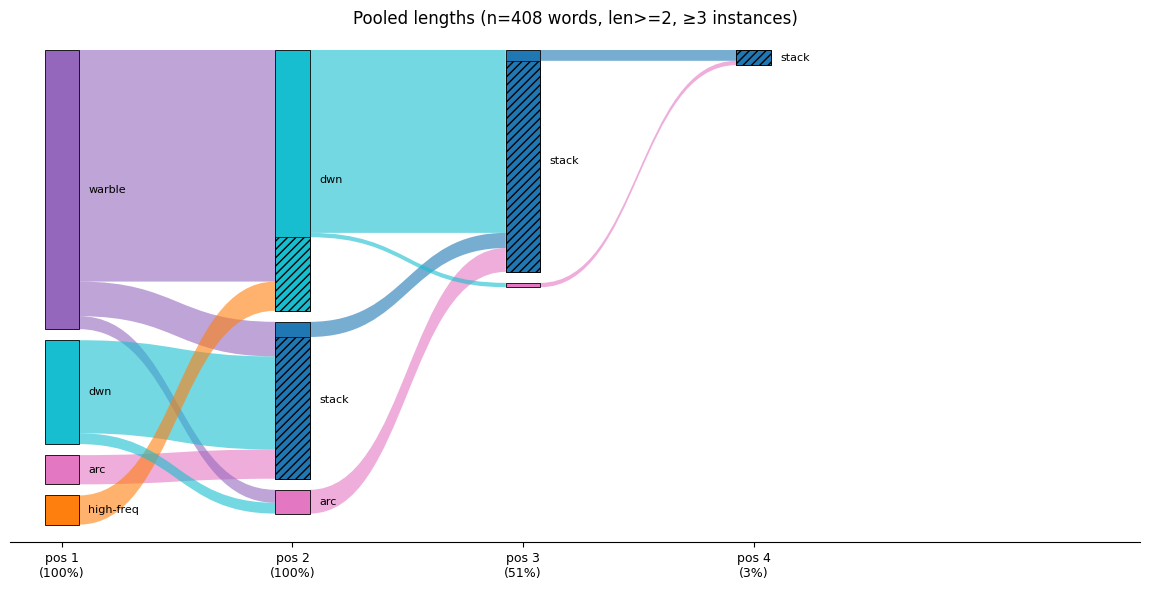

In [103]:
# Pooled alluvial: every word with len>=2 contributes labels to its positions.
# Shorter words leave a stub at their final position (block stays, no outgoing
# ribbon). Subsequences that recur across word lengths pool into thick ribbons.
from matplotlib.patches import Rectangle, PathPatch
from matplotlib.path import Path as _MPath

# Word selection comes from the shared `word-filters` cell (MIN_SYLL, MIN_INSTANCES,
# DROP_SEQUENCES) so this figure always agrees with the motif-slot plots.
chains_pool = FILTERED_CHAINS
n_pool = len(chains_pool)
max_k_pool = max(len(c) for c in chains_pool)

pos_counts_pool = [
    Counter(c[i] for c in chains_pool if len(c) > i) for i in range(max_k_pool)
]
trans_pool = [
    Counter((c[i], c[i + 1]) for c in chains_pool if len(c) > i + 1)
    for i in range(max_k_pool - 1)
]
orders_pool = [sorted(pc.items(), key=lambda x: -x[1]) for pc in pos_counts_pool]
label_idx_pool = [{lab: i for i, (lab, _) in enumerate(o)} for o in orders_pool]

# Endings: ending_counts[col][label] = #words that have `label` at position col+1
# AND end there (len(c) == col + 1).
ending_counts: list[Counter] = []
for col in range(max_k_pool):
    cnt: Counter = Counter()
    for c in chains_pool:
        if len(c) == col + 1:
            cnt[c[col]] += 1
    ending_counts.append(cnt)

GAP_FRAC = 0.025
BLOCK_W = 0.15

blocks_pool: list[dict[str, tuple[float, float]]] = []
for i in range(max_k_pool):
    y = 0.0
    block: dict[str, tuple[float, float]] = {}
    for lab, c in orders_pool[i]:
        block[lab] = (y, y + c / n_pool)
        y += c / n_pool + GAP_FRAC
    blocks_pool.append(block)
y_max = max(b[lab][1] for b in blocks_pool for lab in b)

flows_pool: list[tuple[int, float, float, float, float, str]] = []
for col in range(max_k_pool - 1):
    outgoing: dict[str, list[tuple[str, int]]] = defaultdict(list)
    incoming: dict[str, list[tuple[str, int]]] = defaultdict(list)
    for (src, tgt), c in trans_pool[col].items():
        outgoing[src].append((tgt, c))
        incoming[tgt].append((src, c))
    for lst in outgoing.values():
        lst.sort(key=lambda x: label_idx_pool[col + 1][x[0]])
    for lst in incoming.values():
        lst.sort(key=lambda x: label_idx_pool[col][x[0]])

    src_cursor = {lab: blocks_pool[col][lab][0] for lab in blocks_pool[col]}
    tgt_cursor = {lab: blocks_pool[col + 1][lab][0] for lab in blocks_pool[col + 1]}
    src_band: dict[tuple[str, str], tuple[float, float]] = {}
    tgt_band: dict[tuple[str, str], tuple[float, float]] = {}
    for src, flows in outgoing.items():
        for tgt, c in flows:
            y0 = src_cursor[src]
            h = c / n_pool
            src_band[(src, tgt)] = (y0, y0 + h)
            src_cursor[src] = y0 + h
    for tgt, flows in incoming.items():
        for src, c in flows:
            y0 = tgt_cursor[tgt]
            h = c / n_pool
            tgt_band[(src, tgt)] = (y0, y0 + h)
            tgt_cursor[tgt] = y0 + h
    for (src, tgt) in trans_pool[col]:
        sy0, sy1 = src_band[(src, tgt)]
        ty0, ty1 = tgt_band[(src, tgt)]
        flows_pool.append((col, sy0, sy1, ty0, ty1, COLORS.get(src, "tab:gray")))

fig, ax = plt.subplots(figsize=(2.4 * max_k_pool + 2, 6))

for (col, sy0, sy1, ty0, ty1, color) in flows_pool:
    x0 = col + BLOCK_W
    x1 = col + 1
    mid = 0.5 * (x0 + x1)
    verts = [
        (x0, sy0),
        (mid, sy0), (mid, ty0), (x1, ty0),
        (x1, ty1),
        (mid, ty1), (mid, sy1), (x0, sy1),
        (x0, sy0),
    ]
    codes = [
        _MPath.MOVETO,
        _MPath.CURVE4, _MPath.CURVE4, _MPath.CURVE4,
        _MPath.LINETO,
        _MPath.CURVE4, _MPath.CURVE4, _MPath.CURVE4,
        _MPath.CLOSEPOLY,
    ]
    ax.add_patch(PathPatch(_MPath(verts, codes), facecolor=color,
                           edgecolor="none", alpha=0.6, zorder=1))

for col in range(max_k_pool):
    for lab, (y0, y1) in blocks_pool[col].items():
        color = COLORS.get(lab, "tab:gray")
        ax.add_patch(Rectangle((col, y0), BLOCK_W, y1 - y0,
                               facecolor=color, edgecolor="black",
                               linewidth=0.6, zorder=2))
        count = int(round((y1 - y0) * n_pool))
        # Hatched overlay on the portion that ends here (no outgoing ribbon).
        ends = ending_counts[col].get(lab, 0)
        if ends > 0:
            end_h = ends / n_pool
            ax.add_patch(Rectangle((col, y1 - end_h), BLOCK_W, end_h,
                                   facecolor="none", edgecolor="black",
                                   hatch="////", linewidth=0.5, zorder=2.5))
        if (y1 - y0) > 0.025:
            ax.text(col + BLOCK_W + 0.04, 0.5 * (y0 + y1),
                    lab, ha="left", va="center", fontsize=8, zorder=3)

n_active_per_pos = [
    sum(int(round((b[1] - b[0]) * n_pool)) for b in bp.values())
    for bp in blocks_pool
]
ax.set_xticks([col + BLOCK_W / 2 for col in range(max_k_pool)])
ax.set_xticklabels(
    [f"pos {col + 1}\n({n / n_pool * 100:.0f}%)" for col, n in enumerate(n_active_per_pos)],
    fontsize=9,
)

ax.set_xlim(-0.15, max_k_pool - 1 + BLOCK_W + 1.6)
ax.set_ylim(-0.04, y_max + 0.04)
ax.invert_yaxis()
ax.set_yticks([])
for s in ("top", "right", "left"):
    ax.spines[s].set_visible(False)
ax.set_title(
    f"Pooled lengths (n={n_pool} words, len>=2, ≥{MIN_INSTANCES} instances)"
)
plt.tight_layout()
out_path = VIZ_DIR / "alluvial_pooled.png"
fig.savefig(out_path, dpi=120, bbox_inches="tight")
fig.savefig(out_path.with_suffix(".pdf"), dpi=120, bbox_inches="tight")
print(f"Saved {out_path} and .pdf")
plt.show()


Saved /mnt/home/neurostatslab/ceph/saneslab_data/gily_data/Pre_processing/das/models/TRAINING_data_complex/2026_07_03_dwn_merge/viz_2026_07_03_dwn_merge/alluvial_pooled_fixed_rows.png and .pdf


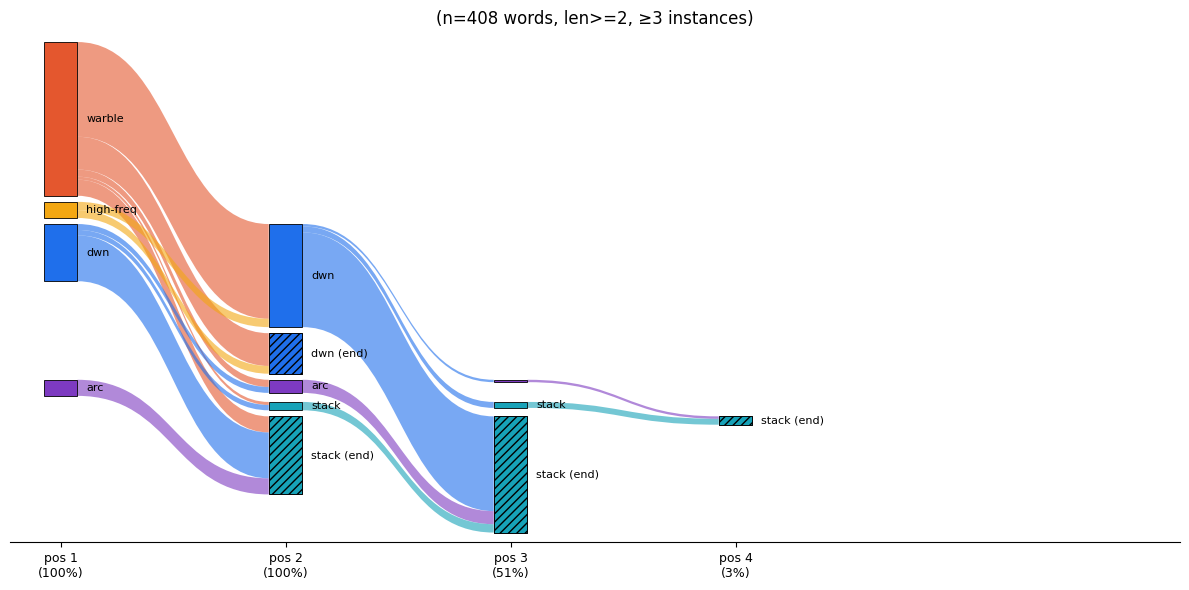

In [104]:
# Pooled alluvial, fixed call-type rows: every call type keeps its own reserved lane
# at every position (warble on top, then high-freq, dwn, arc, stack), instead of blocks
# being re-sorted by frequency at each column.
#
# A `stack` that TERMINATES the motif is its own node ("stack (end)", hatched) and gets
# its own lane, so the ribbons feeding a terminal stack are separate sleeves from those
# feeding a stack that continues. Other call types keep the partial-hatch convention.
#
# Colors come from CALL_COLORS (defined in the essentials cell), matching the motif figures.
# All names are `fr_`-prefixed so this cell cannot clobber the `blocks_pool` / `flows_pool`
# globals that the poster + talk-slide alluvial cells read.
from matplotlib.patches import Rectangle, PathPatch
from matplotlib.path import Path as _MPath

FR_GAP_FRAC = 0.025
FR_BLOCK_W = 0.15
FR_END_SUFFIX = " (end)"
FR_SPLIT_END_LABELS = {"stack", "dwn"}   # these get a separate terminal lane
FR_LANE_ORDER = ["warble", "high-freq",
                 "dwn", "dwn" + FR_END_SUFFIX,
                 "arc",
                 "stack", "stack" + FR_END_SUFFIX]
# Word selection comes from the shared `word-filters` cell.
fr_chains = FILTERED_CHAINS
fr_n = len(fr_chains)
fr_maxk = max(len(c) for c in fr_chains)


def _fr_node(chain, i):
    """node key at position i: split the terminal `stack` into its own node"""
    lab = chain[i]
    if lab in FR_SPLIT_END_LABELS and i == len(chain) - 1:
        return lab + FR_END_SUFFIX
    return lab


def _fr_base(node):
    return node[:-len(FR_END_SUFFIX)] if node.endswith(FR_END_SUFFIX) else node


fr_nodes = [[_fr_node(c, i) for i in range(len(c))] for c in fr_chains]

fr_pos_counts = [Counter(nd[i] for nd in fr_nodes if len(nd) > i) for i in range(fr_maxk)]
fr_trans = [Counter((nd[i], nd[i + 1]) for nd in fr_nodes if len(nd) > i + 1)
            for i in range(fr_maxk - 1)]

# ---- fixed lanes: one reserved row per node type, same y at every position ----
_seen = {l for pc in fr_pos_counts for l in pc}
fr_lanes = [l for l in FR_LANE_ORDER if l in _seen] + sorted(_seen - set(FR_LANE_ORDER))
fr_lane_idx = {lab: i for i, lab in enumerate(fr_lanes)}
fr_lane_h = {lab: max(pc.get(lab, 0) for pc in fr_pos_counts) / fr_n for lab in fr_lanes}

fr_lane_y0, _y = {}, 0.0
for lab in fr_lanes:
    fr_lane_y0[lab] = _y
    _y += fr_lane_h[lab] + FR_GAP_FRAC
fr_ymax = _y - FR_GAP_FRAC

fr_blocks = []
for i in range(fr_maxk):
    fr_blocks.append({lab: (fr_lane_y0[lab], fr_lane_y0[lab] + c / fr_n)
                      for lab, c in fr_pos_counts[i].items()})

# endings: for a "(end)" node this is the whole block; other labels keep a partial hatch
fr_ending = []
for col in range(fr_maxk):
    cnt = Counter()
    for nd in fr_nodes:
        if len(nd) == col + 1:
            cnt[nd[col]] += 1
    fr_ending.append(cnt)

# ---- ribbons (identical logic, lane-ordered) ----
fr_flows = []
for col in range(fr_maxk - 1):
    outgoing, incoming = defaultdict(list), defaultdict(list)
    for (src, tgt), c in fr_trans[col].items():
        outgoing[src].append((tgt, c))
        incoming[tgt].append((src, c))
    for lst in outgoing.values():
        lst.sort(key=lambda x: fr_lane_idx[x[0]])
    for lst in incoming.values():
        lst.sort(key=lambda x: fr_lane_idx[x[0]])

    src_cur = {lab: fr_blocks[col][lab][0] for lab in fr_blocks[col]}
    tgt_cur = {lab: fr_blocks[col + 1][lab][0] for lab in fr_blocks[col + 1]}
    sb, tb = {}, {}
    for src, flows in outgoing.items():
        for tgt, c in flows:
            y0 = src_cur[src]; h = c / fr_n
            sb[(src, tgt)] = (y0, y0 + h); src_cur[src] = y0 + h
    for tgt, flows in incoming.items():
        for src, c in flows:
            y0 = tgt_cur[tgt]; h = c / fr_n
            tb[(src, tgt)] = (y0, y0 + h); tgt_cur[tgt] = y0 + h
    for (src, tgt) in fr_trans[col]:
        sy0, sy1 = sb[(src, tgt)]
        ty0, ty1 = tb[(src, tgt)]
        fr_flows.append((col, sy0, sy1, ty0, ty1,
                         CALL_COLORS.get(_fr_base(src), "tab:gray")))

fig, ax = plt.subplots(figsize=(2.4 * fr_maxk + 2.4, 6))
for (col, sy0, sy1, ty0, ty1, color) in fr_flows:
    x0, x1 = col + FR_BLOCK_W, col + 1
    mid = 0.5 * (x0 + x1)
    verts = [(x0, sy0), (mid, sy0), (mid, ty0), (x1, ty0),
             (x1, ty1), (mid, ty1), (mid, sy1), (x0, sy1), (x0, sy0)]
    codes = [_MPath.MOVETO, _MPath.CURVE4, _MPath.CURVE4, _MPath.CURVE4,
             _MPath.LINETO, _MPath.CURVE4, _MPath.CURVE4, _MPath.CURVE4, _MPath.CLOSEPOLY]
    ax.add_patch(PathPatch(_MPath(verts, codes), facecolor=color,
                           edgecolor="none", alpha=0.6, zorder=1))

for col in range(fr_maxk):
    for lab, (y0, y1) in fr_blocks[col].items():
        color = CALL_COLORS.get(_fr_base(lab), "tab:gray")
        ax.add_patch(Rectangle((col, y0), FR_BLOCK_W, y1 - y0, facecolor=color,
                               edgecolor="black", linewidth=0.6, zorder=2))
        ends = fr_ending[col].get(lab, 0)
        if ends > 0:
            end_h = ends / fr_n
            ax.add_patch(Rectangle((col, y1 - end_h), FR_BLOCK_W, end_h, facecolor="none",
                                   edgecolor="black", hatch="////", linewidth=0.5, zorder=2.5))
        if (y1 - y0) > 0.02:
            ax.text(col + FR_BLOCK_W + 0.04, 0.5 * (y0 + y1), lab,
                    ha="left", va="center", fontsize=8, zorder=3)

fr_active = [sum(int(round((b[1] - b[0]) * fr_n)) for b in bp.values()) for bp in fr_blocks]
ax.set_xticks([col + FR_BLOCK_W / 2 for col in range(fr_maxk)])
ax.set_xticklabels([f"pos {col + 1}\n({n / fr_n * 100:.0f}%)"
                    for col, n in enumerate(fr_active)], fontsize=9)
ax.set_xlim(-0.15, fr_maxk - 1 + FR_BLOCK_W + 1.9)
ax.set_ylim(-0.04, fr_ymax + 0.04)
ax.invert_yaxis()
ax.set_yticks([])
for s in ("top", "right", "left"):
    ax.spines[s].set_visible(False)
_fr_split = "/".join(sorted(FR_SPLIT_END_LABELS))
ax.set_title(f"(n={fr_n} words, len>={MIN_SYLL}, ≥{MIN_INSTANCES} instances)")
plt.tight_layout()
_fr_out = VIZ_DIR / "alluvial_pooled_fixed_rows.png"
fig.savefig(_fr_out, dpi=120, bbox_inches="tight")
fig.savefig(_fr_out.with_suffix(".pdf"), dpi=120, bbox_inches="tight")
print(f"Saved {_fr_out} and .pdf")
plt.show()


Saved /mnt/home/neurostatslab/ceph/saneslab_data/gily_data/Pre_processing/das/models/TRAINING_data_complex/2026_07_03_dwn_merge/viz_2026_07_03_dwn_merge/alluvial_prefix_aligned.png and .pdf


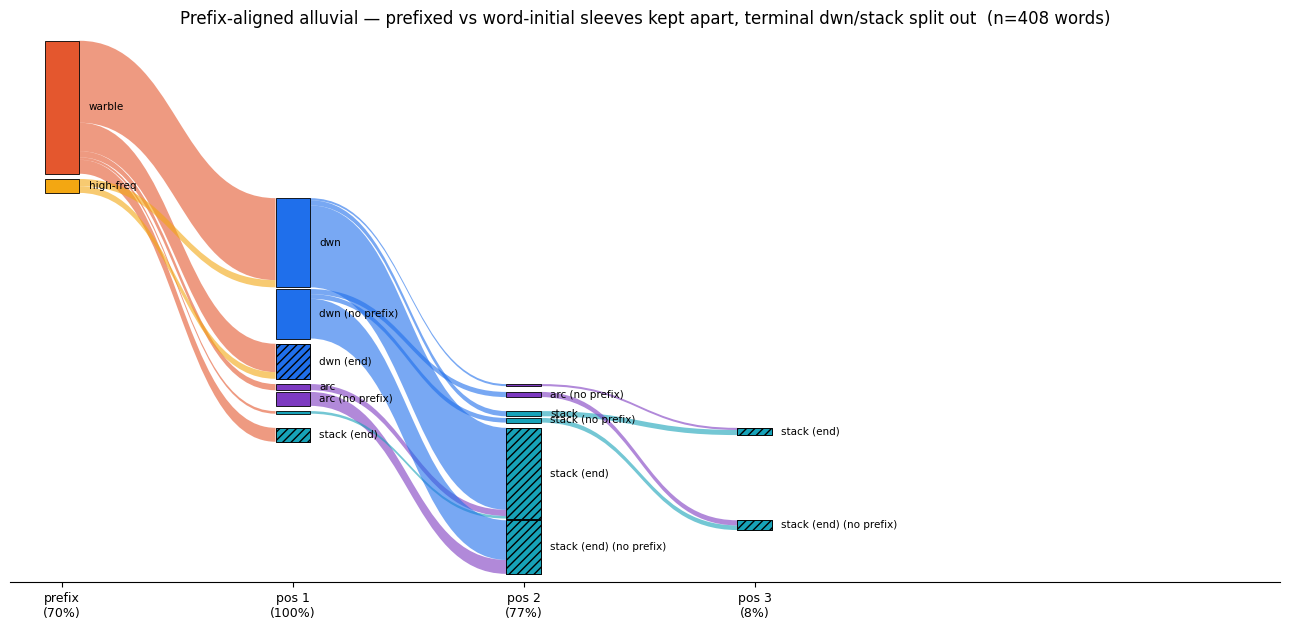

In [ ]:
# Prefix-aligned alluvial: fixed call-type rows + terminal `(end)` splits, with columns
# indexed like the motif-slot plots.
#
#   warble / high-freq occupy their own `prefix` column, and everything strung after them
#   shifts back one column, so `dwn → stack` aligns its dwn with `warble → dwn → stack`.
#
#   Each call-type lane is further split into two sub-bands, separated by a SMALL gap:
#       top    = the call inside a word that HAS a prefix   (e.g. warble → dwn → stack)
#       bottom = the call inside a word with NO prefix      (e.g.          dwn → stack)
#   The two sleeves stay separate through every column, so the prefixed and unprefixed
#   variants of the same motif never merge into one block.
#
# Word selection comes from the shared `word-filters` cell. Colors from CALL_COLORS.
# All names are `pa_`-prefixed so nothing here clobbers the pooled / fixed-row globals.
from matplotlib.patches import Rectangle, PathPatch
from matplotlib.path import Path as _MPath

PA_PREFIXES = {"warble", "high-freq"}
PA_GAP_FRAC = 0.025          # gap between different call types
PA_SUB_GAP = 0.008           # gap between the prefixed / unprefixed sub-bands
PA_BLOCK_W = 0.15
PA_END_SUFFIX = " (end)"
PA_SPLIT_END_LABELS = {"stack", "dwn"}
PA_LANE_ORDER = ["warble", "high-freq",
                 "dwn", "dwn" + PA_END_SUFFIX,
                 "arc",
                 "stack", "stack" + PA_END_SUFFIX]

pa_chains = FILTERED_CHAINS
pa_n = len(pa_chains)


def _pa_node(chain, i):
    lab = chain[i]
    if lab in PA_SPLIT_END_LABELS and i == len(chain) - 1:
        return lab + PA_END_SUFFIX
    return lab


def _pa_base(node):
    return node[:-len(PA_END_SUFFIX)] if node.endswith(PA_END_SUFFIX) else node


def _pa_cols(chain):
    """(column, (node, has_prefix)) per call; prefix-openers start at col 0, others col 1."""
    pfx = chain[0] in PA_PREFIXES
    off = 0 if pfx else 1
    return [(i + off, (_pa_node(chain, i), pfx)) for i in range(len(chain))]


pa_words = [_pa_cols(c) for c in pa_chains]
pa_ncol = max(col for w in pa_words for col, _ in w) + 1

pa_pos_counts = [Counter() for _ in range(pa_ncol)]
pa_trans = [Counter() for _ in range(pa_ncol - 1)]
pa_ending = [Counter() for _ in range(pa_ncol)]
for w in pa_words:
    for col, key in w:
        pa_pos_counts[col][key] += 1
    for (c0, k0), (c1, k1) in zip(w, w[1:]):
        pa_trans[c0][(k0, k1)] += 1
    _c, _k = w[-1]
    pa_ending[_c][_k] += 1

# ---- sub-lanes: (call type, has_prefix). prefixed band sits above the unprefixed one ----
_seen = {k for pc in pa_pos_counts for k in pc}
pa_sublanes = [(lab, p) for lab in PA_LANE_ORDER for p in (True, False) if (lab, p) in _seen]
pa_sublanes += sorted(_seen - set(pa_sublanes))
pa_lane_idx = {k: i for i, k in enumerate(pa_sublanes)}
pa_lane_h = {k: max(pc.get(k, 0) for pc in pa_pos_counts) / pa_n for k in pa_sublanes}

pa_lane_y0, _y = {}, 0.0
for _i, key in enumerate(pa_sublanes):
    pa_lane_y0[key] = _y
    _y += pa_lane_h[key]
    if _i + 1 < len(pa_sublanes):
        _y += PA_SUB_GAP if pa_sublanes[_i + 1][0] == key[0] else PA_GAP_FRAC
pa_ymax = _y

pa_blocks = [{k: (pa_lane_y0[k], pa_lane_y0[k] + c / pa_n) for k, c in pc.items()}
             for pc in pa_pos_counts]

# ---- ribbons (a word never changes its prefix status, so sleeves never cross) ----
pa_flows = []
for col in range(pa_ncol - 1):
    outgoing, incoming = defaultdict(list), defaultdict(list)
    for (src, tgt), c in pa_trans[col].items():
        outgoing[src].append((tgt, c))
        incoming[tgt].append((src, c))
    for lst in outgoing.values():
        lst.sort(key=lambda x: pa_lane_idx[x[0]])
    for lst in incoming.values():
        lst.sort(key=lambda x: pa_lane_idx[x[0]])

    src_cur = {k: pa_blocks[col][k][0] for k in pa_blocks[col]}
    tgt_cur = {k: pa_blocks[col + 1][k][0] for k in pa_blocks[col + 1]}
    sb, tb = {}, {}
    for src, flows in outgoing.items():
        for tgt, c in flows:
            y0 = src_cur[src]; h = c / pa_n
            sb[(src, tgt)] = (y0, y0 + h); src_cur[src] = y0 + h
    for tgt, flows in incoming.items():
        for src, c in flows:
            y0 = tgt_cur[tgt]; h = c / pa_n
            tb[(src, tgt)] = (y0, y0 + h); tgt_cur[tgt] = y0 + h
    for (src, tgt) in pa_trans[col]:
        sy0, sy1 = sb[(src, tgt)]
        ty0, ty1 = tb[(src, tgt)]
        pa_flows.append((col, sy0, sy1, ty0, ty1,
                         CALL_COLORS.get(_pa_base(src[0]), "tab:gray")))

fig, ax = plt.subplots(figsize=(2.6 * pa_ncol + 2.6, 6.4))
for (col, sy0, sy1, ty0, ty1, color) in pa_flows:
    x0, x1 = col + PA_BLOCK_W, col + 1
    mid = 0.5 * (x0 + x1)
    verts = [(x0, sy0), (mid, sy0), (mid, ty0), (x1, ty0),
             (x1, ty1), (mid, ty1), (mid, sy1), (x0, sy1), (x0, sy0)]
    codes = [_MPath.MOVETO, _MPath.CURVE4, _MPath.CURVE4, _MPath.CURVE4,
             _MPath.LINETO, _MPath.CURVE4, _MPath.CURVE4, _MPath.CURVE4, _MPath.CLOSEPOLY]
    ax.add_patch(PathPatch(_MPath(verts, codes), facecolor=color,
                           edgecolor="none", alpha=0.6, zorder=1))

for col in range(pa_ncol):
    for (lab, pfx), (y0, y1) in pa_blocks[col].items():
        ax.add_patch(Rectangle((col, y0), PA_BLOCK_W, y1 - y0,
                               facecolor=CALL_COLORS.get(_pa_base(lab), "tab:gray"),
                               edgecolor="black", linewidth=0.6, zorder=2))
        ends = pa_ending[col].get((lab, pfx), 0)
        if ends > 0:
            ax.add_patch(Rectangle((col, y1 - ends / pa_n), PA_BLOCK_W, ends / pa_n,
                                   facecolor="none", edgecolor="black",
                                   hatch="////", linewidth=0.5, zorder=2.5))
        if (y1 - y0) > 0.018:
            txt = lab if pfx else f"{lab} (no prefix)"
            ax.text(col + PA_BLOCK_W + 0.04, 0.5 * (y0 + y1), txt,
                    ha="left", va="center", fontsize=7.5, zorder=3)

pa_active = [sum(pc.values()) for pc in pa_pos_counts]
ax.set_xticks([col + PA_BLOCK_W / 2 for col in range(pa_ncol)])
ax.set_xticklabels([f"{'prefix' if col == 0 else f'pos {col}'}\n({n / pa_n * 100:.0f}%)"
                    for col, n in enumerate(pa_active)], fontsize=9)
ax.set_xlim(-0.15, pa_ncol - 1 + PA_BLOCK_W + 2.2)
ax.set_ylim(-0.04, pa_ymax + 0.04)
ax.invert_yaxis()
ax.set_yticks([])
for s in ("top", "right", "left"):
    ax.spines[s].set_visible(False)
_pa_split = "/".join(sorted(PA_SPLIT_END_LABELS))
ax.set_title(f"terminal {_pa_split} split out  (n={pa_n} words)")
plt.tight_layout()
_pa_out = VIZ_DIR / "alluvial_prefix_aligned.png"
fig.savefig(_pa_out, dpi=120, bbox_inches="tight")
fig.savefig(_pa_out.with_suffix(".pdf"), dpi=120, bbox_inches="tight")
print(f"Saved {_pa_out} and .pdf")
plt.show()


In [ ]:
# === PREP for ALL motif-slot plots ===
# Everything the motif-slot figures share: cutoffs, the kept sequence set, per-word
# provenance (family / recording location), the fixed slot layout, and the drawers.
# The plot cells below are thin callers. Requires the essentials cell.
import re
import shutil

# ---------------- palette + layout constants ----------------
# CALL_COLORS comes from the essentials cell (single source of truth, shared with
# the fixed-row alluvial).
ARROW_COLOR = "0.55"
BAR_COLOR = "#c7ced6"
COL_MULT = 1.30                 # horizontal column spacing (lower = tighter)

# ---------------- cutoffs ----------------
PREFIXES = ["warble", "high-freq"]     # calls that can occupy the prefix slot
# MIN_SYLL / MIN_INSTANCES / DROP_SEQUENCES all come from the shared `word-filters` cell.

# ---------------- provenance ----------------
# `exp` -> recording month ("family"/date folder); `channel` -> assigned_location
# (matches the DAS all_calls output: 10=arena_1, 20=arena_2, 30=underground).
EXP2FAMILY = {97: "2024_12", 235: "2025_03", 273: "2025_07", 275: "2025_07",
              334: "2025_10", 335: "2025_10", 336: "2025_10", 337: "2025_10",
              497: "2026_02"}
CHANNEL2LOC = {10: "arena_1", 20: "arena_2", 30: "underground"}


def _file_meta(stem: str):
    m = re.search(r"exp_(\d+)_channel_(\d+)", stem)
    if m:
        exp, ch = int(m.group(1)), int(m.group(2))
    else:
        m2 = re.search(r"^channel_(\d+)_", stem)
        exp, ch = None, (int(m2.group(1)) if m2 else None)
    return exp, ch, EXP2FAMILY.get(exp, "unknown"), CHANNEL2LOC.get(ch, "unknown")


# ---------------- one record per word (chain), with provenance ----------------
_rows = []
for _stem, _df in all_ann.groupby("file_stem", sort=False):
    _df = _df.sort_values("onset_s").reset_index(drop=True)
    _exp, _ch, _fam, _loc = _file_meta(_stem)
    _cur = [_df.iloc[0]["label"]]
    for _i in range(1, len(_df)):
        if float(_df.iloc[_i]["onset_s"]) - float(_df.iloc[_i - 1]["offset_s"]) <= SEQ_THRESHOLD_S:
            _cur.append(_df.iloc[_i]["label"])
        else:
            _rows.append((_stem, _fam, _loc, tuple(_cur)))
            _cur = [_df.iloc[_i]["label"]]
    _rows.append((_stem, _fam, _loc, tuple(_cur)))

words_df = pd.DataFrame(_rows, columns=["file_stem", "family", "location", "sequence"])
words_df["n_calls"] = words_df["sequence"].map(len)

# ---------------- the kept sequence set (shared by every motif-slot plot) ----------------
kept: dict = dict(KEPT_SEQ_COUNTS)      # from the shared `word-filters` cell

print(f"kept sequences: {len(kept)}   words: {sum(kept.values())}")
print("\nwords (len>=2) per family:")
print(words_df[words_df["n_calls"] >= 2].groupby("family").size().to_string())
print("\nwords (len>=2) per location:")
print(words_df[words_df["n_calls"] >= 2].groupby("location").size().to_string())

# ---------------- fixed slot layout:  prefix | dwn | arc | stack | stack ----------------
N_END = max(s.count("stack") for s in kept)
NCOL = 3 + N_END
FIXED_COL = {"warble": 0, "high-freq": 0, "dwn": 1, "arc": 2}
END_COLS = list(range(3, 3 + N_END))


def assign_slots(seq):
    """map each call in a sequence to its fixed column"""
    slots, si = {}, 0
    for tok in seq:
        if tok == "stack":
            slots[END_COLS[min(si, N_END - 1)]] = tok
            si += 1
        else:
            slots[FIXED_COL[tok]] = tok
    return slots


REPO_VIZ_DIR = REPO_ROOT / "data" / "complex_calls_viz" / DATA_DIR.name
REPO_VIZ_DIR.mkdir(parents=True, exist_ok=True)


# ---------------- shared drawing helpers ----------------
def _dw_factory(fig, ax):
    fig.canvas.draw()
    rend = fig.canvas.get_renderer()
    inv = ax.transData.inverted()
    def dw(t):
        bb = t.get_window_extent(renderer=rend)
        (x0, _), (x1, _) = inv.transform((0, 0)), inv.transform((bb.width, 0))
        return abs(x1 - x0)
    return dw


def _col_setup(fig, ax, xmax, col_mult=COL_MULT):
    """iterate until column width + xlim converge; returns (Xc, W)"""
    ax.set_xlim(0, xmax * 1.14)
    for _ in range(3):
        dw = _dw_factory(fig, ax)
        ref = ax.text(0, 0, "high-freq", fontsize=9, fontweight="bold")
        W = dw(ref) * col_mult
        ref.remove()
        Xc = [-W * 0.55 - (NCOL - 1 - k) * W for k in range(NCOL)]
        ax.set_xlim(Xc[0] - W * 0.85, xmax * 1.14)
    return Xc, W


def _draw_tokens(fig, ax, rows, Xc, W):
    """rows: [(y, sequence)] -> colored call tokens + connecting arrows"""
    placed = []
    for y, seq in rows:
        slots = assign_slots(seq)
        objs = []
        for col in sorted(slots):
            tok = slots[col]
            t = ax.text(Xc[col], y, tok, ha="center", va="center", fontsize=9,
                        fontweight="bold", color=CALL_COLORS[tok], clip_on=False, zorder=3)
            objs.append((col, t))
        placed.append((y, objs))
    dw = _dw_factory(fig, ax)
    pad = W * 0.06
    for y, objs in placed:
        for (ca, ta), (cb, tb) in zip(objs, objs[1:]):
            ax.annotate("", xy=(Xc[cb] - dw(tb) / 2 - pad, y),
                        xytext=(Xc[ca] + dw(ta) / 2 + pad, y),
                        arrowprops=dict(arrowstyle="->", color=ARROW_COLOR, lw=0.9,
                                        shrinkA=0, shrinkB=0),
                        zorder=3, annotation_clip=False)


def _draw_headers(ax, Xc, y_hdr):
    ax.text(Xc[0], y_hdr, "prefix", ha="center", va="center", fontsize=9,
            color="0.35", style="italic", clip_on=False)
    ax.text(0.5 * (Xc[1] + Xc[2]), y_hdr, "intermediate", ha="center", va="center",
            fontsize=9, color="0.35", style="italic", clip_on=False)
    ax.text(0.5 * (Xc[3] + Xc[-1]), y_hdr, "end", ha="center", va="center",
            fontsize=9, color="0.35", style="italic", clip_on=False)


def _save(fig, fname):
    fig.savefig(VIZ_DIR / fname, dpi=140, bbox_inches="tight")
    shutil.copyfile(VIZ_DIR / fname, REPO_VIZ_DIR / fname)
    print(f"Saved {fname} → {VIZ_DIR} and {REPO_VIZ_DIR}")


# ---------------- drawer 1: plain motif slots ----------------
def draw_motif_slots(group_by_length: bool, fname: str, title: str):
    rows, groups, pos = [], [], 0.0
    if group_by_length:
        by_len: dict = {}
        for seq, cnt in kept.items():
            by_len.setdefault(len(seq), []).append((seq, cnt))
        for L in sorted(by_len):
            by_len[L].sort(key=lambda x: -x[1])
            groups.append((L, -pos))
            for seq, cnt in by_len[L]:
                rows.append((-pos, cnt, seq)); pos += 1.0
            pos += 1.0
    else:
        for seq, cnt in sorted(kept.items(), key=lambda x: -x[1]):
            rows.append((-pos, cnt, seq)); pos += 1.0

    ys = [r[0] for r in rows]; counts = [r[1] for r in rows]
    xmax = max(counts)
    fig, ax = plt.subplots(figsize=(14, 0.42 * len(rows) + (2.0 if group_by_length else 1.6)))
    ax.barh(ys, counts, height=0.7, color=BAR_COLOR, edgecolor="white", linewidth=0.6, zorder=2)
    ax.set_yticks([]); ax.set_xlabel("count")
    for y, cnt in zip(ys, counts):
        ax.text(cnt + xmax * 0.008, y, str(int(cnt)), va="center", fontsize=8, color="0.35")

    Xc, W = _col_setup(fig, ax, xmax)
    ax.set_xticks(np.arange(0, xmax + 1, 25))
    _draw_tokens(fig, ax, [(y, s) for y, _, s in rows], Xc, W)

    y_hdr = max(ys) + 1.15
    _draw_headers(ax, Xc, y_hdr)
    for L, y_top in groups:
        ax.text(Xc[0] - W * 0.75, y_top, f"{L} calls", ha="right", va="center",
                fontsize=9, color="0.45", style="italic", clip_on=False)

    ax.set_ylim(min(ys) - 0.9, y_hdr + 0.6)
    for s in ("top", "right", "left"):
        ax.spines[s].set_visible(False)
    present = [c for c in CALL_COLORS if any(c in seq for _, _, seq in rows)]
    handles = [plt.Line2D([0], [0], marker="s", ls="", color=CALL_COLORS[c],
                          label=c, markersize=10) for c in present]
    ax.legend(handles=handles, loc="lower right", fontsize=9, frameon=False, title="call type")
    ax.set_title(f"{title}   (≥{MIN_SYLL} syll, ≥{MIN_INSTANCES} inst — "
                 f"{len(rows)} sequences, {sum(counts)} words)")
    plt.tight_layout(); _save(fig, fname); plt.show()


# ---------------- drawer 2: split by group (counts | normalized + prior) ----------------
def draw_grouped_slots(counts_by_group, group_order, group_colors, title, fname):
    seqs = sorted(kept, key=lambda s: -sum(counts_by_group[g].get(s, 0) for g in group_order))
    mat = np.array([[counts_by_group[g].get(s, 0) for g in group_order] for s in seqs], float)
    tot_seq = mat.sum(axis=1)
    prior = mat.sum(axis=0)                       # per-group totals = the data prior
    priorn = prior / prior.sum()
    matn = np.divide(mat, tot_seq[:, None], out=np.zeros_like(mat), where=tot_seq[:, None] > 0)

    y_seq = [-i for i in range(len(seqs))]
    y_prior = 1.5
    xmax = tot_seq.max()

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 0.46 * len(seqs) + 3.2), sharey=True,
                                   gridspec_kw={"width_ratios": [1.45, 1.0], "wspace": 0.05})
    left = np.zeros(len(seqs))
    for j, g in enumerate(group_order):
        ax1.barh(y_seq, mat[:, j], left=left, height=0.66, color=group_colors[g],
                 edgecolor="white", linewidth=0.6, zorder=2)
        left += mat[:, j]
    for y, tot in zip(y_seq, tot_seq):
        ax1.text(tot + xmax * 0.012, y, str(int(tot)), va="center", fontsize=8, color="0.35")
    ax1.set_xlabel("count"); ax1.set_title("counts", fontsize=10, color="0.3")

    left = np.zeros(len(seqs)); lp = 0.0
    for j, g in enumerate(group_order):
        ax2.barh(y_seq, matn[:, j], left=left, height=0.66, color=group_colors[g],
                 edgecolor="white", linewidth=0.6, zorder=2,
                 label=f"{g}  (n={int(prior[j])})")
        ax2.barh([y_prior], [priorn[j]], left=[lp], height=0.66, color=group_colors[g],
                 edgecolor="white", linewidth=0.8, zorder=2)
        left += matn[:, j]; lp += priorn[j]
    ax2.set_xlim(0, 1.0); ax2.set_xticks(np.arange(0, 1.01, 0.25))
    ax2.set_xlabel("fraction of that sequence's words")
    ax2.set_title("normalized per sequence", fontsize=10, color="0.3")
    ax2.text(1.02, y_prior, f"n={int(prior.sum())}", va="center", fontsize=8, color="0.35")
    for ax in (ax1, ax2):
        ax.axhline(0.75, color="0.75", lw=0.8, ls=":", zorder=1)

    ax1.set_yticks([])
    Xc, W = _col_setup(fig, ax1, xmax)
    ax1.set_xticks(np.arange(0, xmax + 1, max(25, int(xmax // 6 // 25) * 25 or 25)))
    _draw_tokens(fig, ax1, list(zip(y_seq, seqs)), Xc, W)

    ax1.text(0.5 * (Xc[0] + Xc[-1]), y_prior, "prior — all words", ha="center", va="center",
             fontsize=9, color="0.35", style="italic", clip_on=False)
    y_hdr = y_prior + 1.05
    _draw_headers(ax1, Xc, y_hdr)
    ax1.set_ylim(min(y_seq) - 0.9, y_hdr + 0.6)
    for ax in (ax1, ax2):
        for sp in ("top", "right", "left"):
            ax.spines[sp].set_visible(False)
    ax2.legend(loc="center left", bbox_to_anchor=(1.06, 0.5), fontsize=9,
               frameon=False, title="group  (total words)")
    fig.suptitle(title, y=1.0)
    plt.tight_layout(); _save(fig, fname); plt.show()


print("\nprep ready → kept, words_df, assign_slots, draw_motif_slots(), draw_grouped_slots()")


In [ ]:
# === Motif slots — plain (all words) ===
# Thin caller. Requires the motif-slots prep cell above.
draw_motif_slots(True,  "motif_slots_rows.png",
                 "Motif slots: prefix | dwn | arc | stack | stack")
draw_motif_slots(False, "motif_slots_by_count.png",
                 "Motif slots — sorted by occurrences")


In [ ]:
# === Motif slots — split BY FAMILY (date folder) ===
# Left panel = raw counts, right = normalized per sequence with a `prior` row showing
# how all words distribute across families. Requires the motif-slots prep cell above.
FAMILY_ORDER = ["2024_12", "2025_03", "2025_07", "2025_10", "2026_02", "unknown"]
_present = [f for f in FAMILY_ORDER if (words_df["family"] == f).any()]
_cmap = plt.get_cmap("Set2")
FAMILY_COLORS = {f: _cmap(i % 8) for i, f in enumerate(_present)}

counts_by_family = {f: Counter(words_df.loc[words_df["family"] == f, "sequence"])
                    for f in _present}

print("kept-sequence words per family (the prior):")
_tot = {f: sum(counts_by_family[f].get(s, 0) for s in kept) for f in _present}
for f, n in _tot.items():
    print(f"  {f:<9} {n:>4}   ({n / sum(_tot.values()) * 100:5.1f}%)")

draw_grouped_slots(counts_by_family, _present, FAMILY_COLORS,
                   "Motif slots by family (date folder)",
                   "motif_slots_by_family.png")


In [ ]:
# === Coarse motif slots:  prefix | intermediate | stack ===
# Collapse the vocabulary to three call types:
#     warble, high-freq  ->  prefix
#     dwn, arc           ->  intermediate
#     stack              ->  stack
# then merge any run of consecutive identical calls, so a double stack becomes one
# stack and dwn→arc becomes a single intermediate.
#
# Regroups the SAME words as the motif-slots cell above — run that cell first (uses `kept`).
import shutil

COARSE_MAP = {"warble": "prefix", "high-freq": "prefix",
              "dwn": "intermediate", "arc": "intermediate", "stack": "stack"}
COARSE_COLORS = {"prefix": "#e4572e", "intermediate": "#4c6ef5", "stack": "#17a2b8"}
COARSE_ORDER = ["prefix", "intermediate", "stack"]      # fixed column order
C_ARROW = "0.55"
C_BAR = "#c7ced6"
C_COL_MULT = 1.25


def coarsen(seq):
    """map to 3 call types, then collapse runs of consecutive identical calls"""
    out = []
    for tok in (COARSE_MAP[t] for t in seq):
        if not out or out[-1] != tok:
            out.append(tok)
    return tuple(out)


coarse = Counter()
merge_log: dict = {}
for seq, cnt in kept.items():
    cs = coarsen(seq)
    coarse[cs] += cnt
    merge_log.setdefault(cs, []).append((seq, cnt))

print(f"Coarse sequences (regrouping the same {sum(kept.values())} words):\n")
for cs, n in coarse.most_common():
    print(f"  {n:>4}  {' → '.join(cs)}")
    for seq, c in sorted(merge_log[cs], key=lambda x: -x[1]):
        print(f"              {c:>4}  ←  {' → '.join(seq)}")
print()

# ---- fixed slots: prefix | intermediate | stack ----
C_NCOL = len(COARSE_ORDER)
COARSE_COL = {name: i for i, name in enumerate(COARSE_ORDER)}

def coarse_slots(cs):
    slots = {}
    for tok in cs:
        col = COARSE_COL[tok]
        assert col not in slots, f"slot collision in {cs!r} — a call type repeats non-adjacently"
        slots[col] = tok
    return slots


rows = [(-i * 1.0, cnt, cs) for i, (cs, cnt) in enumerate(coarse.most_common())]
ys = [r[0] for r in rows]; counts = [r[1] for r in rows]
xmax = max(counts)

REPO_VIZ_DIR = REPO_ROOT / "data" / "complex_calls_viz" / DATA_DIR.name
REPO_VIZ_DIR.mkdir(parents=True, exist_ok=True)

fig, ax = plt.subplots(figsize=(12, 0.55 * len(rows) + 2.0))
ax.barh(ys, counts, height=0.6, color=C_BAR, edgecolor="white", linewidth=0.6, zorder=2)
ax.set_yticks([]); ax.set_xlabel("count")
ax.set_xticks(np.arange(0, xmax + 1, 25))
for y, cnt in zip(ys, counts):
    ax.text(cnt + xmax * 0.008, y, str(int(cnt)), va="center", fontsize=9, color="0.35")

def _widths():
    fig.canvas.draw()
    rend = fig.canvas.get_renderer()
    inv = ax.transData.inverted()
    def dw(t):
        bb = t.get_window_extent(renderer=rend)
        (x0, _), (x1, _) = inv.transform((0, 0)), inv.transform((bb.width, 0))
        return abs(x1 - x0)
    return dw

ax.set_xlim(0, xmax * 1.12)
for _ in range(3):
    dw = _widths()
    _ref = ax.text(0, 0, "intermediate", fontsize=10, fontweight="bold")
    W = dw(_ref) * C_COL_MULT
    _ref.remove()
    Xc = [-W * 0.55 - (C_NCOL - 1 - k) * W for k in range(C_NCOL)]
    ax.set_xlim(Xc[0] - W * 0.85, xmax * 1.12)
dw = _widths()

placed = []
for (y, cnt, cs) in rows:
    slots = coarse_slots(cs)
    objs = []
    for col in sorted(slots):
        tok = slots[col]
        t = ax.text(Xc[col], y, tok, ha="center", va="center", fontsize=10, fontweight="bold",
                    color=COARSE_COLORS[tok], clip_on=False, zorder=3)
        objs.append((col, t))
    placed.append((y, objs))

fig.canvas.draw()
pad = W * 0.05
for (y, objs) in placed:
    for (ca, ta), (cb, tb) in zip(objs, objs[1:]):
        ax.annotate("", xy=(Xc[cb] - dw(tb) / 2 - pad, y),
                    xytext=(Xc[ca] + dw(ta) / 2 + pad, y),
                    arrowprops=dict(arrowstyle="->", color=C_ARROW, lw=1.0,
                                    shrinkA=0, shrinkB=0),
                    zorder=3, annotation_clip=False)

y_hdr = max(ys) + 1.0
for name, col in COARSE_COL.items():
    ax.text(Xc[col], y_hdr, name, ha="center", va="center", fontsize=9,
            color="0.35", style="italic", clip_on=False)

ax.set_ylim(min(ys) - 0.8, y_hdr + 0.6)
for s in ("top", "right", "left"):
    ax.spines[s].set_visible(False)
handles = [plt.Line2D([0], [0], marker="s", ls="", color=COARSE_COLORS[c], label=c, markersize=10)
           for c in COARSE_ORDER]
ax.legend(handles=handles, loc="lower right", fontsize=9, frameon=False, title="call type")
ax.set_title(f"Coarse motif slots — prefix | intermediate | stack   "
             f"({len(rows)} sequences, {sum(counts)} words)")
plt.tight_layout()
_fname = "motif_slots_coarse.png"
fig.savefig(VIZ_DIR / _fname, dpi=140, bbox_inches="tight")
shutil.copyfile(VIZ_DIR / _fname, REPO_VIZ_DIR / _fname)
print(f"Saved {_fname} → {VIZ_DIR} and {REPO_VIZ_DIR}")
plt.show()


In [30]:
from __future__ import annotations

import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

REPO_ROOT = Path("/mnt/home/gginosar/repos/gerbil_vocalization_analysis")
sys.path.insert(0, str(REPO_ROOT))

from vocalization_analysis.spectrogram_viz import read_audio
from vocalization_analysis.spectrogram_viz import plot_spectrogram, plot_segments_overlay, COLOR_MAP

_PARENT_DIR = Path(
    "/mnt/home/neurostatslab/ceph/saneslab_data/gily_data/Pre_processing/das/models/TRAINING_data_complex"
)
# Current working set. Other folders: latest, with_dwn_stack, 235.
DATA_DIR = _PARENT_DIR / "2026_07_03_dwn_merge"
VIZ_DIR = DATA_DIR / f"viz_{DATA_DIR.name}"
VIZ_DIR.mkdir(parents=True, exist_ok=True)
print(f"Data dir: {DATA_DIR}")
print(f"Saving figures to: {VIZ_DIR}")
MIN_FREQ = 1_000
MAX_FREQ = 60_000

# Normalize variant/typo annotation spellings on load (CSVs left untouched).
LABEL_NORMALIZE = {
    "down-stack": "dwn-stack",   # 2026_07_02_all spells it this way
    "arc-atck":   "arc-stack",   # typo
    "stacks":     "stack",       # stray/typo (real label is singular "stack")
}


Data dir: /mnt/home/neurostatslab/ceph/saneslab_data/gily_data/Pre_processing/das/models/TRAINING_data_complex/2026_07_03_dwn_merge
Saving figures to: /mnt/home/neurostatslab/ceph/saneslab_data/gily_data/Pre_processing/das/models/TRAINING_data_complex/2026_07_03_dwn_merge/viz_2026_07_03_dwn_merge


In [31]:
# Extend the pipeline COLOR_MAP with labels that only appear in the complex set.
EXTRA_COLORS = {
    "stack": "tab:blue",
    "half-arc": "tab:olive",
    "arc-stack": "tab:brown",
    "arc": "tab:pink",
    "dwn-stack": "tab:cyan",
    "dwn": "tab:cyan",
}
COLORS = {**COLOR_MAP, **EXTRA_COLORS}


In [32]:
def find_pairs(data_dir: Path) -> list[tuple[Path, Path]]:
    pairs = []
    for wav in sorted(data_dir.glob("*.wav")):
        csv = wav.with_name(wav.stem + "_annotations.csv")
        if csv.exists():
            pairs.append((wav, csv))
        else:
            print(f"[warn] no annotations for {wav.name}")
    return pairs


def load_annotations(csv_path: Path) -> pd.DataFrame:
    df = pd.read_csv(csv_path)
    # DAS export prepends a class-registration row per label with NaN start,
    # stop=0, channel=-1. Drop these — they are not real annotations.
    df = df.dropna(subset=["start_seconds"]).reset_index(drop=True)
    # Reuse the pipeline overlay helper, which expects label/onset_s/offset_s.
    df = df.rename(
        columns={"name": "label", "start_seconds": "onset_s", "stop_seconds": "offset_s"}
    )
    # Normalize variant/typo spellings (see LABEL_NORMALIZE in the essentials cell).
    df["label"] = df["label"].replace(LABEL_NORMALIZE)
    return df


pairs = find_pairs(DATA_DIR)
print(f"Found {len(pairs)} wav/csv pairs.")

# Build a single long-form annotations table with file provenance.
rows = []
for wav, csv in pairs:
    df = load_annotations(csv)
    df["file_stem"] = wav.stem
    df["wav_path"] = str(wav)
    rows.append(df)
all_ann = pd.concat(rows, ignore_index=True)
all_ann["duration_s"] = all_ann["offset_s"] - all_ann["onset_s"]

# Heads-up: any label that only ever appeared as a class-registration row
# (NaN start) ends up with zero real instances after the dropna above.
declared_labels = set()
for _, csv in pairs:
    declared_labels.update(pd.read_csv(csv)["name"].unique())
empty_labels = sorted(declared_labels - set(all_ann["label"].unique()))
if empty_labels:
    print(f"\n[note] declared but never actually annotated: {empty_labels}")

print("\nLabel counts (real annotations only):")
print(all_ann["label"].value_counts())
print("\nDuration stats per label (seconds):")
print(all_ann.groupby("label")["duration_s"].describe()[["count", "mean", "min", "max"]])

Found 61 wav/csv pairs.

[note] declared but never actually annotated: ['half-arc-stack', 'newborn', 'noise']

Label counts (real annotations only):
label
dwn          753
stack        542
warble       495
high-freq    117
arc           95
alarm          1
Name: count, dtype: int64

Duration stats per label (seconds):
           count      mean       min       max
label                                         
alarm        1.0  0.114923  0.114923  0.114923
arc         95.0  0.071073  0.015597  0.354115
dwn        753.0  0.082894 -0.115743  0.452265
high-freq  117.0  0.025334  0.004681  0.099861
stack      542.0  0.110435 -0.041566  0.481969
warble     495.0  0.047175 -0.158153  0.316921


## 3. Within-word transition matrix

Two calls are "in the same word" if the next call starts within `GAP_THRESHOLD_S` of the current call's offset (negative gaps = overlap also count). Rows = preceding call, columns = following call. Left heatmap: raw transition counts. Right heatmap: row-normalized — `P(next | current)`.

n consecutive pairs: 1942  | min: -103.4 ms, p25: 4.6 ms, median: 75.6 ms, p75: 166.2 ms, max: 7606.1 ms
Negative gaps (overlapping calls): 6
Saved /mnt/home/neurostatslab/ceph/saneslab_data/gily_data/Pre_processing/das/models/TRAINING_data_complex/2026_07_03_dwn_merge/viz_2026_07_03_dwn_merge/gap_histogram.png and .pdf


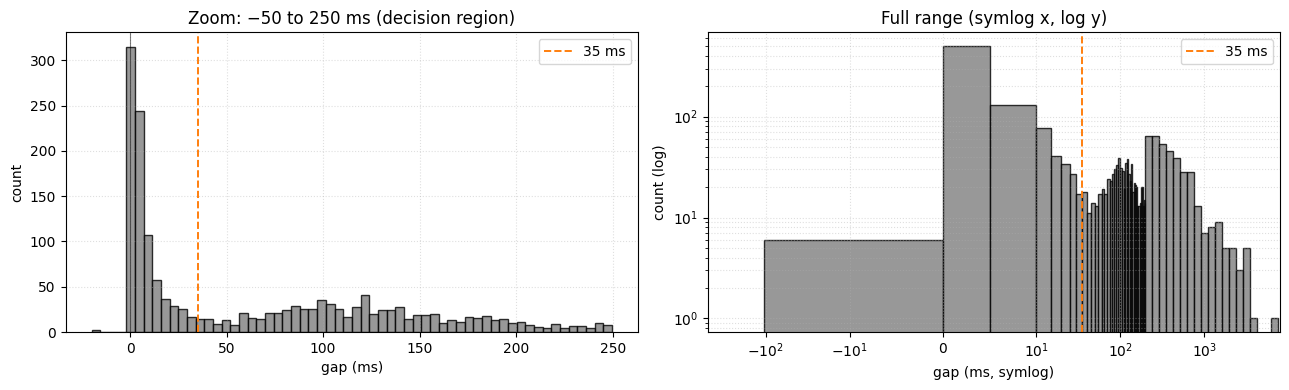

In [33]:
# Inter-call gap distribution — use this to pick the within-word threshold.
# This threshold drives the word-length, sequence-frequency, and transition-matrix cells below.
GAP_THRESHOLDS_S = (0.035,)
THR_COLORS = {0.035: "tab:orange"}

gaps_ms: list[float] = []
for stem, df in all_ann.groupby("file_stem", sort=False):
    df = df.sort_values("onset_s").reset_index(drop=True)
    for i in range(len(df) - 1):
        gap = float(df.iloc[i + 1]["onset_s"]) - float(df.iloc[i]["offset_s"])
        gaps_ms.append(gap * 1000)
gaps_arr = np.array(gaps_ms)

print(
    f"n consecutive pairs: {len(gaps_arr)}  | "
    f"min: {gaps_arr.min():.1f} ms, "
    f"p25: {np.percentile(gaps_arr, 25):.1f} ms, "
    f"median: {np.median(gaps_arr):.1f} ms, "
    f"p75: {np.percentile(gaps_arr, 75):.1f} ms, "
    f"max: {gaps_arr.max():.1f} ms"
)
print(f"Negative gaps (overlapping calls): {(gaps_arr < 0).sum()}")

fig, (ax_zoom, ax_full) = plt.subplots(1, 2, figsize=(13, 4))

# Left: zoomed-in linear-scale view of the within-word decision region.
ax_zoom.hist(
    gaps_arr[(gaps_arr >= -50) & (gaps_arr <= 250)],
    bins=60, color="tab:gray", edgecolor="black", alpha=0.8,
)
for thr in GAP_THRESHOLDS_S:
    ax_zoom.axvline(thr * 1000, color=THR_COLORS[thr], linestyle="--",
                    linewidth=1.4, label=f"{thr * 1000:.0f} ms")
ax_zoom.axvline(0, color="black", linewidth=0.8, alpha=0.5)
ax_zoom.set_xlabel("gap (ms)")
ax_zoom.set_ylabel("count")
ax_zoom.set_title("Zoom: −50 to 250 ms (decision region)")
ax_zoom.legend()
ax_zoom.grid(linestyle=":", alpha=0.4)

# Right: full-range view, log y-scale so the long tail is visible.
bin_edges = np.concatenate([
    np.array([gaps_arr.min() - 1]),
    np.linspace(0, 200, 41),
    np.geomspace(200, gaps_arr.max() + 1, 20),
])
ax_full.hist(gaps_arr, bins=bin_edges, color="tab:gray", edgecolor="black", alpha=0.8)
for thr in GAP_THRESHOLDS_S:
    ax_full.axvline(thr * 1000, color=THR_COLORS[thr], linestyle="--",
                    linewidth=1.4, label=f"{thr * 1000:.0f} ms")
ax_full.set_xscale("symlog", linthresh=10)
ax_full.set_yscale("log")
ax_full.set_xlabel("gap (ms, symlog)")
ax_full.set_ylabel("count (log)")
ax_full.set_title("Full range (symlog x, log y)")
ax_full.legend()
ax_full.grid(linestyle=":", alpha=0.4, which="both")

plt.tight_layout()
out_path = VIZ_DIR / "gap_histogram.png"
fig.savefig(out_path, dpi=120, bbox_inches="tight")
fig.savefig(out_path.with_suffix(".pdf"), dpi=120, bbox_inches="tight")
print(f"Saved {out_path} and .pdf")
plt.show()

### Word-length distribution

Group calls into "words" (chains of consecutive calls separated by ≤ threshold). One bar per word length so you can see how often calls go solo vs. chain into 2-, 3-, 4-syllable words.


=== gap ≤ 35 ms ===
1166 words covering 2003 calls. Singletons: 666 (57%), multi-syllable: 500 (43%).
Word length — mean: 1.72, median: 1, max: 8

Saved /mnt/home/neurostatslab/ceph/saneslab_data/gily_data/Pre_processing/das/models/TRAINING_data_complex/2026_07_03_dwn_merge/viz_2026_07_03_dwn_merge/word_length_histogram.png and .pdf


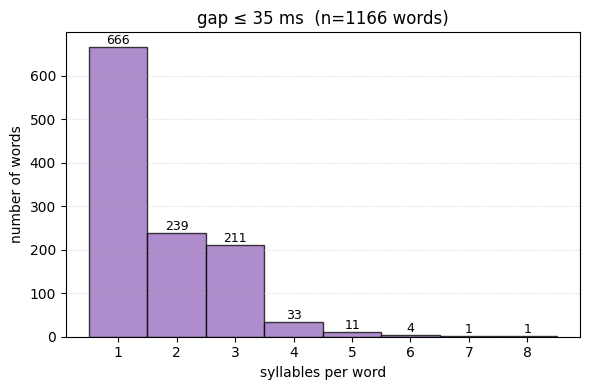

In [34]:
def build_chains(threshold_s: float) -> list[list[str]]:
    """Group consecutive calls into words separated by gaps > threshold_s."""
    chains: list[list[str]] = []
    for stem, df in all_ann.groupby("file_stem", sort=False):
        df = df.sort_values("onset_s").reset_index(drop=True)
        if df.empty:
            continue
        current = [df.iloc[0]["label"]]
        for i in range(1, len(df)):
            gap = float(df.iloc[i]["onset_s"]) - float(df.iloc[i - 1]["offset_s"])
            if gap <= threshold_s:
                current.append(df.iloc[i]["label"])
            else:
                chains.append(current)
                current = [df.iloc[i]["label"]]
        chains.append(current)
    return chains


fig, axes = plt.subplots(1, len(GAP_THRESHOLDS_S), figsize=(6 * len(GAP_THRESHOLDS_S), 4),
                         squeeze=False)
axes = axes[0]

for ax, thr in zip(axes, GAP_THRESHOLDS_S):
    chains = build_chains(thr)
    lengths = np.array([len(c) for c in chains])
    n_words = len(chains)
    n_calls = lengths.sum()
    n_singleton = (lengths == 1).sum()
    n_multi = (lengths > 1).sum()
    print(f"\n=== gap ≤ {thr * 1000:.0f} ms ===")
    print(f"{n_words} words covering {n_calls} calls. "
          f"Singletons: {n_singleton} ({n_singleton/n_words:.0%}), "
          f"multi-syllable: {n_multi} ({n_multi/n_words:.0%}).")
    print(f"Word length — mean: {lengths.mean():.2f}, median: {int(np.median(lengths))}, max: {lengths.max()}")

    max_len = lengths.max()
    bins = np.arange(0.5, max_len + 1.5, 1.0)
    ax.hist(lengths, bins=bins, color="tab:purple", edgecolor="black", alpha=0.75)
    ax.set_xticks(range(1, max_len + 1))
    ax.set_xlabel("syllables per word")
    ax.set_ylabel("number of words")
    ax.set_title(f"gap ≤ {thr * 1000:.0f} ms  (n={n_words} words)")
    ax.grid(axis="y", linestyle=":", alpha=0.5)
    # Annotate each bar with its count.
    counts, _ = np.histogram(lengths, bins=bins)
    for k, c in enumerate(counts, start=1):
        if c > 0:
            ax.text(k, c, str(int(c)), ha="center", va="bottom", fontsize=9)

plt.tight_layout()
out_path = VIZ_DIR / "word_length_histogram.png"
fig.savefig(out_path, dpi=120, bbox_inches="tight")
fig.savefig(out_path.with_suffix(".pdf"), dpi=120, bbox_inches="tight")
print(f"\nSaved {out_path} and .pdf")
plt.show()

### Bigram syllable graph

Compact view: nodes are syllables, edges are bigram transitions pooled across every word and every position. Edge width ∝ bigram count, color = source. Self-loops show within-word repetition (e.g. `arc-stack → arc-stack`). A recurring motif like `stack → arc-stack → arc-stack` shows up as a chain of thick edges in this graph — reuse from different words and different positions aggregates into a single edge instead of being split across separate prefix-tree branches.


In [ ]:
# Bigram graph: every bigram in every length-≥2 word pooled into one edge.
# Nodes = syllables, circular layout ordered by marginal count.
import numpy as np
from matplotlib.patches import FancyArrowPatch, Circle, PathPatch
from matplotlib.path import Path as _MPath

node_counts = Counter(s for c in chains_pool for s in c)
bigram_counts: Counter = Counter()
for c in chains_pool:
    for i in range(len(c) - 1):
        bigram_counts[(c[i], c[i + 1])] += 1

start_counts = Counter(c[0] for c in chains_pool)
end_counts = Counter(c[-1] for c in chains_pool)

nodes = [lab for lab, _ in node_counts.most_common()]
n_nodes = len(nodes)
node_idx = {lab: i for i, lab in enumerate(nodes)}

# Circular layout: position 0 at top, clockwise.
RADIUS = 1.0
angles = {
    lab: np.pi / 2 - 2 * np.pi * i / n_nodes for i, lab in enumerate(nodes)
}
positions = {
    lab: (RADIUS * np.cos(angles[lab]), RADIUS * np.sin(angles[lab]))
    for lab in nodes
}

max_bigram = max(bigram_counts.values())
max_node = max(node_counts.values())

def edge_width(c: int) -> float:
    return 0.4 + 6.0 * c / max_bigram

def node_radius(c: int) -> float:
    return 0.06 + 0.12 * (c / max_node) ** 0.5

# Pixel-radius for arrow shrink so heads stop at the node boundary.
def shrink_pts(lab: str) -> float:
    return 72 * node_radius(node_counts[lab])

EDGE_LABEL_MIN = max(3, max_bigram // 6)  # only annotate the heavier edges

fig, ax = plt.subplots(figsize=(10, 10))

# Edges first (so nodes sit on top).
for (src, tgt), c in bigram_counts.items():
    color = COLORS.get(src, "tab:gray")
    w = edge_width(c)
    if src == tgt:
        # Self-loop: cubic Bezier that bulges radially outward.
        x, y = positions[src]
        ang = angles[src]
        dx, dy = np.cos(ang), np.sin(ang)
        px, py = -dy, dx
        bulge = 0.35
        side = 0.22
        cp1 = (x + bulge * dx + side * px, y + bulge * dy + side * py)
        cp2 = (x + bulge * dx - side * px, y + bulge * dy - side * py)
        path = _MPath(
            [(x, y), cp1, cp2, (x, y)],
            [_MPath.MOVETO, _MPath.CURVE4, _MPath.CURVE4, _MPath.CURVE4],
        )
        ax.add_patch(PathPatch(path, facecolor="none", edgecolor=color,
                               linewidth=w, alpha=0.75, zorder=1))
        if c >= EDGE_LABEL_MIN:
            lx = x + 1.05 * bulge * dx
            ly = y + 1.05 * bulge * dy
            ax.text(lx, ly, str(c), ha="center", va="center",
                    fontsize=8, color="black", zorder=4,
                    bbox=dict(facecolor="white", edgecolor="none",
                              boxstyle="round,pad=0.1", alpha=0.7))
    else:
        x0, y0 = positions[src]
        x1, y1 = positions[tgt]
        # Bend forward and reverse edges in opposite directions.
        rad = 0.18 if node_idx[src] < node_idx[tgt] else -0.18
        arrow = FancyArrowPatch(
            (x0, y0), (x1, y1),
            connectionstyle=f"arc3,rad={rad}",
            arrowstyle="-|>",
            mutation_scale=8 + 2 * w,
            linewidth=w,
            color=color,
            alpha=0.75,
            shrinkA=shrink_pts(src),
            shrinkB=shrink_pts(tgt),
            zorder=1,
        )
        ax.add_patch(arrow)
        if c >= EDGE_LABEL_MIN:
            # Midpoint along the curve, offset perpendicular toward the bulge.
            mx, my = 0.5 * (x0 + x1), 0.5 * (y0 + y1)
            ex, ey = x1 - x0, y1 - y0
            L = np.hypot(ex, ey) or 1.0
            # Perpendicular unit, pointing toward the bulge side.
            perp = (-ey / L, ex / L)
            off = rad * 0.45
            lx, ly = mx + off * perp[0], my + off * perp[1]
            ax.text(lx, ly, str(c), ha="center", va="center",
                    fontsize=8, color="black", zorder=4,
                    bbox=dict(facecolor="white", edgecolor="none",
                              boxstyle="round,pad=0.1", alpha=0.7))

# Nodes.
for lab in nodes:
    x, y = positions[lab]
    r = node_radius(node_counts[lab])
    color = COLORS.get(lab, "tab:gray")
    ax.add_patch(Circle((x, y), r, facecolor=color, edgecolor="black",
                        linewidth=1.0, zorder=3))
    ang = angles[lab]
    label_r = RADIUS + r + 0.08
    lx, ly = label_r * np.cos(ang), label_r * np.sin(ang)
    cos_a, sin_a = np.cos(ang), np.sin(ang)
    ha = "left" if cos_a > 0.15 else ("right" if cos_a < -0.15 else "center")
    va = "bottom" if sin_a > 0.15 else ("top" if sin_a < -0.15 else "center")
    ax.text(
        lx, ly,
        f"{lab}\n(n={node_counts[lab]})\n"
        f"S:{start_counts.get(lab, 0)}  E:{end_counts.get(lab, 0)}",
        ha=ha, va=va, fontsize=9, fontweight="bold", zorder=4,
    )

ax.set_xlim(-1.8, 1.8)
ax.set_ylim(-1.8, 1.8)
ax.set_aspect("equal")
ax.axis("off")
ax.set_title(
    f"Bigram syllable graph (n={len(chains_pool)} words, len>=2)\n"
    "node size ∝ marginal count  |  edge width ∝ bigram count, color = source\n"
    "node label: S = #words starting with this label, E = #words ending with it\n"
    f"edge counts shown when ≥ {EDGE_LABEL_MIN}"
)
plt.tight_layout()
out_path = VIZ_DIR / "bigram_graph.png"
fig.savefig(out_path, dpi=120, bbox_inches="tight")
fig.savefig(out_path.with_suffix(".pdf"), dpi=120, bbox_inches="tight")
print(f"Saved {out_path} and .pdf")
plt.show()



=== Threshold: gap <= 20 ms ===
Within-word transitions: 86 | END transitions: 120
Within-word gap stats — min: -40.4 ms, median: 2.5 ms, max: 17.9 ms
Dropped to END (gap > 20 ms but next call exists): 108
  [channel_4_156_complex]  stack → warble  (gap 81.2 ms)
  [channel_4_156_complex]  warble → stack  (gap 40.7 ms)
  [channel_4_156_complex]  stack → warble  (gap 95.8 ms)
  [channel_4_156_complex]  stack → warble  (gap 119.1 ms)
  [channel_4_156_complex]  warble → stack  (gap 25.1 ms)
  [channel_4_156_complex]  arc-stack → warble  (gap 113.6 ms)
  [channel_4_156_complex]  warble → arc  (gap 72.5 ms)
  [channel_4_156_complex]  stack → warble  (gap 113.7 ms)
  [channel_4_156_complex]  warble → warble  (gap 209.4 ms)
  [channel_4_156_complex]  stack → warble  (gap 122.7 ms)
  [channel_6_61_complex]  warble → warble  (gap 488.4 ms)
  [channel_6_61_complex]  warble → warble  (gap 711.3 ms)
  [channel_6_61_complex]  stack → warble  (gap 112.3 ms)
  [channel_6_61_complex]  stack → warble  

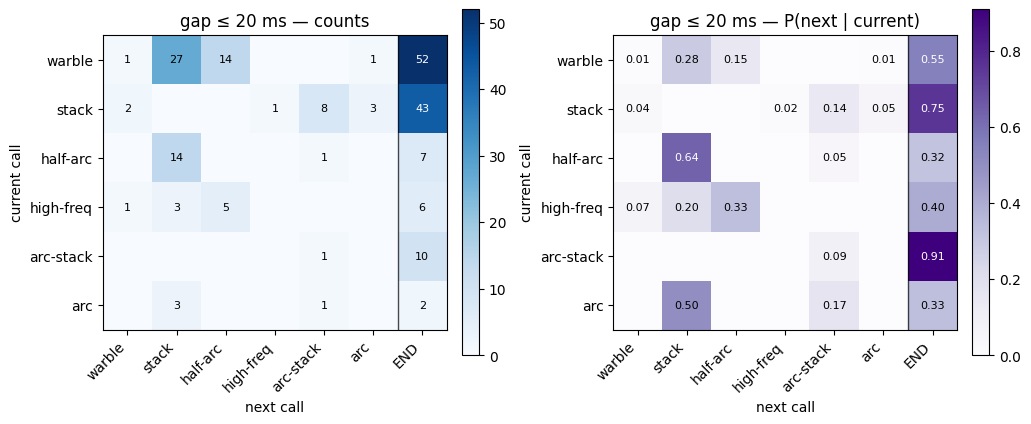


=== Threshold: gap <= 50 ms ===
Within-word transitions: 96 | END transitions: 110
Within-word gap stats — min: -40.4 ms, median: 2.9 ms, max: 49.1 ms
Dropped to END (gap > 50 ms but next call exists): 98
  [channel_4_156_complex]  stack → warble  (gap 81.2 ms)
  [channel_4_156_complex]  stack → warble  (gap 95.8 ms)
  [channel_4_156_complex]  stack → warble  (gap 119.1 ms)
  [channel_4_156_complex]  arc-stack → warble  (gap 113.6 ms)
  [channel_4_156_complex]  warble → arc  (gap 72.5 ms)
  [channel_4_156_complex]  stack → warble  (gap 113.7 ms)
  [channel_4_156_complex]  warble → warble  (gap 209.4 ms)
  [channel_4_156_complex]  stack → warble  (gap 122.7 ms)
  [channel_6_61_complex]  warble → warble  (gap 488.4 ms)
  [channel_6_61_complex]  warble → warble  (gap 711.3 ms)
  [channel_6_61_complex]  stack → warble  (gap 112.3 ms)
  [channel_6_61_complex]  stack → warble  (gap 127.4 ms)
  [channel_6_61_complex]  stack → warble  (gap 136.9 ms)
  [channel_6_61_complex]  stack → warble  (

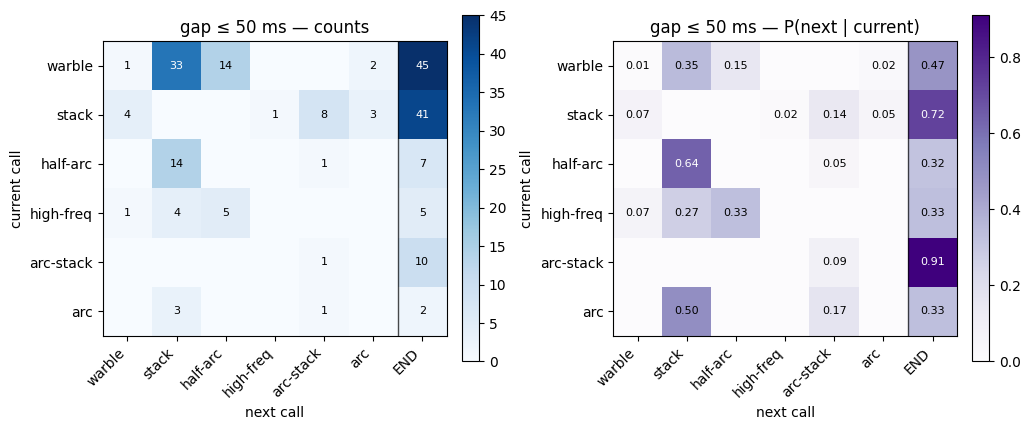

In [6]:
# GAP_THRESHOLDS_S is defined in the gap-histogram cell above.

# Order labels by frequency so reading the matrix matches the per-type figures.
labels = all_ann["label"].value_counts().index.tolist()
label_to_idx = {lbl: i for i, lbl in enumerate(labels)}
n_labels = len(labels)
col_labels = labels + ["END"]
n_cols = n_labels + 1


def build_transitions(threshold_s: float):
    counts = np.zeros((n_labels, n_cols), dtype=int)
    gaps_within: list[float] = []
    dropped: list[tuple[str, str, str, float]] = []  # (file, prev, next, gap_ms)
    for stem, df in all_ann.groupby("file_stem", sort=False):
        df = df.sort_values("onset_s").reset_index(drop=True)
        for i in range(len(df)):
            cur = df.iloc[i]
            cur_idx = label_to_idx[cur["label"]]
            if i == len(df) - 1:
                # Last call in file: natural END.
                counts[cur_idx, n_labels] += 1
                continue
            nxt = df.iloc[i + 1]
            gap = float(nxt["onset_s"]) - float(cur["offset_s"])
            if gap <= threshold_s:
                counts[cur_idx, label_to_idx[nxt["label"]]] += 1
                gaps_within.append(gap)
            else:
                # Gap too big → motif boundary, fold into END.
                counts[cur_idx, n_labels] += 1
                dropped.append((stem, cur["label"], nxt["label"], gap * 1000))
    return counts, gaps_within, dropped


for thr in GAP_THRESHOLDS_S:
    counts, gaps_within, dropped = build_transitions(thr)
    row_sums = counts.sum(axis=1, keepdims=True)
    probs = np.divide(
        counts, row_sums, out=np.zeros_like(counts, dtype=float), where=row_sums > 0
    )

    print(f"\n=== Threshold: gap <= {thr * 1000:.0f} ms ===")
    within_total = counts[:, :n_labels].sum()
    end_total = counts[:, n_labels].sum()
    print(f"Within-word transitions: {within_total} | END transitions: {end_total}")
    if gaps_within:
        print(
            f"Within-word gap stats — min: {min(gaps_within) * 1000:.1f} ms, "
            f"median: {np.median(gaps_within) * 1000:.1f} ms, "
            f"max: {max(gaps_within) * 1000:.1f} ms"
        )
    print(f"Dropped to END (gap > {thr * 1000:.0f} ms but next call exists): {len(dropped)}")
    for stem, prev, nxt, gap_ms in dropped:
        print(f"  [{stem}]  {prev} → {nxt}  (gap {gap_ms:.1f} ms)")

    fig, (ax_c, ax_p) = plt.subplots(
        1, 2, figsize=(2 + 1.0 * n_cols * 1.2, 1.2 + 0.6 * n_labels)
    )
    for ax, mat, ttl, fmt, cmap in [
        (ax_c, counts, "counts", "d", "Blues"),
        (ax_p, probs, "P(next | current)", ".2f", "Purples"),
    ]:
        im = ax.imshow(mat, cmap=cmap, aspect="equal")
        ax.set_xticks(range(n_cols))
        ax.set_yticks(range(n_labels))
        ax.set_xticklabels(col_labels, rotation=45, ha="right")
        ax.set_yticklabels(labels)
        ax.set_xlabel("next call")
        ax.set_ylabel("current call")
        ax.set_title(f"gap ≤ {thr * 1000:.0f} ms — {ttl}")
        # Mark END column boundary so it visually reads as separate.
        ax.axvline(n_labels - 0.5, color="black", linewidth=1.0, alpha=0.7)
        vmax = mat.max() if mat.size else 0
        for i in range(n_labels):
            for j in range(n_cols):
                v = mat[i, j]
                if (fmt == "d" and v == 0) or (fmt == ".2f" and v == 0.0):
                    continue
                color = "white" if v > 0.55 * vmax else "black"
                ax.text(j, i, format(v, fmt), ha="center", va="center", color=color, fontsize=8)
        fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04, shrink=0.85)

    plt.tight_layout()
    out_path = VIZ_DIR / f"transition_matrix_gap{int(thr * 1000):02d}ms.png"
    fig.savefig(out_path, dpi=120, bbox_inches="tight")
    fig.savefig(out_path.with_suffix(".pdf"), dpi=120, bbox_inches="tight")
    print(f"Saved {out_path} and .pdf")
    plt.show()

### Layered bigram DAG

Same bigram graph, but laid out left-to-right by compositional role:
- **Layer 1** (start-prone): `warble`, `high-freq`, `arc`
- **Layer 2**: `half-arc`
- **Layer 3**: `stack`
- **Layer 4** (end-prone): `arc-stack` (and `dwn-stack` when present)

Small inbound stubs on the left = word-start counts; small outbound stubs on the right = word-end counts (per node, sized by count). Forward edges run straight; backward edges (e.g. `stack → warble`) arc upward over the layout to flag them as atypical. Self-loops sit above each node.


In [ ]:
# Layered DAG view of the bigram graph. Layers and per-node y positions are
# hand-coded so the layout reads cleanly; tune below.
import numpy as np
from matplotlib.patches import FancyArrowPatch, Circle, PathPatch, Polygon
from matplotlib.path import Path as _MPath

LAYERS_CONFIG = [
    ["warble", "high-freq"],
    ["half-arc", "arc"],
    ["stack"],
    ["arc-stack", "dwn-stack"],
]

# Per-label y override so layers don't share y-coordinates. Anything not in
# this dict gets auto-stacked within its layer.
NODE_Y = {
    "warble":    1.2,
    "high-freq": -1.2,
    "half-arc":  0.3,
    "arc":       -2.2,
    "stack":     0.0,
    "arc-stack": -0.6,
    "dwn-stack": 1.2,
}

EDGE_COLOR = "0.2"   # near-black for all edges, stubs, and self-loops
LAYER_GAP  = 2.8

# Filter to labels present in the loaded data.
present = set(node_counts)
LAYERS = [[lab for lab in L if lab in present] for L in LAYERS_CONFIG]
LAYERS = [L for L in LAYERS if L]
n_layers = len(LAYERS)
unassigned = sorted(set(present) - {lab for L in LAYERS for lab in L})
if unassigned:
    print(f"[warn] labels not in LAYERS_CONFIG (skipped): {unassigned}")

layer_of = {lab: i for i, L in enumerate(LAYERS) for lab in L}

positions: dict[str, tuple[float, float]] = {}
for i, L in enumerate(LAYERS):
    x = i * LAYER_GAP
    auto = [lab for lab in L if lab not in NODE_Y]
    n_auto = len(auto)
    auto_sorted = sorted(auto, key=lambda lab: -node_counts[lab])
    if n_auto == 1:
        positions[auto_sorted[0]] = (x, 0.0)
    elif n_auto > 1:
        ys = np.linspace((n_auto - 1) / 2, -(n_auto - 1) / 2, n_auto) * 1.7
        for lab, y in zip(auto_sorted, ys):
            positions[lab] = (x, y)
    for lab in L:
        if lab in NODE_Y:
            positions[lab] = (x, NODE_Y[lab])

bigrams_drawn = {(s, t): c for (s, t), c in bigram_counts.items()
                 if s in positions and t in positions}
max_bigram = max(bigrams_drawn.values()) if bigrams_drawn else 1
max_node = max(node_counts.values())
max_start = max(start_counts.values()) if start_counts else 1
max_end = max(end_counts.values()) if end_counts else 1

def edge_width(c): return 0.4 + 5.5 * c / max_bigram
def node_radius(c): return 0.20 + 0.30 * (c / max_node) ** 0.5
def stub_width(c, mx): return 0.5 + 4.0 * c / mx
def shrink_pts(lab): return 72 * node_radius(node_counts[lab]) * 0.6

EDGE_LABEL_MIN = max(5, max_bigram // 6)

fig, ax = plt.subplots(figsize=(13, 8))

# --- helper: draw an arrowhead triangle at `tip` pointing along (dx, dy) ---
def draw_arrowhead(tip, dx, dy, color, size=0.13):
    L = float(np.hypot(dx, dy)) or 1.0
    ux, uy = dx / L, dy / L
    px, py = -uy, ux
    base = (tip[0] - size * ux, tip[1] - size * uy)
    left = (base[0] + size * 0.45 * px, base[1] + size * 0.45 * py)
    right = (base[0] - size * 0.45 * px, base[1] - size * 0.45 * py)
    ax.add_patch(Polygon([tip, left, right], facecolor=color, edgecolor="none",
                         zorder=2.5))

# --- edges ---
for (src, tgt), c in bigrams_drawn.items():
    w = edge_width(c)

    if src == tgt:
        x, y = positions[src]
        r = node_radius(node_counts[src])
        bulge = r + 0.45
        side  = r + 0.30
        start = (x - 0.05, y + r * 0.85)
        end   = (x + 0.05, y + r * 0.85)
        cp1   = (x - side, y + bulge)
        cp2   = (x + side, y + bulge)
        path = _MPath(
            [start, cp1, cp2, end],
            [_MPath.MOVETO, _MPath.CURVE4, _MPath.CURVE4, _MPath.CURVE4],
        )
        ax.add_patch(PathPatch(path, facecolor="none", edgecolor=EDGE_COLOR,
                               linewidth=w, alpha=0.85, zorder=2))
        # Arrowhead at end, tangent direction ≈ end - cp2.
        draw_arrowhead(end, end[0] - cp2[0], end[1] - cp2[1], EDGE_COLOR,
                       size=0.12 + 0.02 * w)
        if c >= EDGE_LABEL_MIN:
            ax.text(x, y + bulge + 0.05, str(c), ha="center", va="bottom",
                    fontsize=8, zorder=5,
                    bbox=dict(facecolor="white", edgecolor="none",
                              boxstyle="round,pad=0.1", alpha=0.7))
        continue

    x0, y0 = positions[src]
    x1, y1 = positions[tgt]
    ls, lt = layer_of[src], layer_of[tgt]
    if ls < lt:
        rad = 0.0
        z = 1
    elif ls > lt:
        rad = -0.40
        z = 2
    else:
        rad = 0.25 if y0 > y1 else -0.25
        z = 1

    arrow = FancyArrowPatch(
        (x0, y0), (x1, y1),
        connectionstyle=f"arc3,rad={rad}",
        arrowstyle="-|>",
        mutation_scale=10 + 2 * w,
        linewidth=w,
        color=EDGE_COLOR,
        alpha=0.85,
        shrinkA=shrink_pts(src),
        shrinkB=shrink_pts(tgt),
        zorder=z,
    )
    ax.add_patch(arrow)

    if c >= EDGE_LABEL_MIN:
        mx, my = 0.5 * (x0 + x1), 0.5 * (y0 + y1)
        dx, dy = x1 - x0, y1 - y0
        L = np.hypot(dx, dy) or 1.0
        perp_x, perp_y = -dy / L, dx / L
        off = -rad * L * 0.5
        lx = mx + off * perp_x
        ly = my + off * perp_y
        ax.text(lx, ly, str(c), ha="center", va="center",
                fontsize=8, zorder=5,
                bbox=dict(facecolor="white", edgecolor="none",
                          boxstyle="round,pad=0.1", alpha=0.75))

# --- start stubs (left) ---
STUB_LEN = 0.7
for lab, (x, y) in positions.items():
    s = start_counts.get(lab, 0)
    if s == 0:
        continue
    r = node_radius(node_counts[lab])
    sx = x - r - STUB_LEN
    w = stub_width(s, max_start)
    arrow = FancyArrowPatch(
        (sx, y), (x, y),
        arrowstyle="-|>",
        mutation_scale=8 + 1.5 * w,
        linewidth=w,
        color=EDGE_COLOR,
        alpha=0.9,
        shrinkA=0,
        shrinkB=shrink_pts(lab),
        zorder=0,
    )
    ax.add_patch(arrow)
    ax.text(sx - 0.08, y, f"{s}", ha="right", va="center",
            fontsize=8, color="0.2", zorder=4)

# --- end stubs (right) ---
for lab, (x, y) in positions.items():
    e = end_counts.get(lab, 0)
    if e == 0:
        continue
    r = node_radius(node_counts[lab])
    ex = x + r + STUB_LEN
    w = stub_width(e, max_end)
    arrow = FancyArrowPatch(
        (x, y), (ex, y),
        arrowstyle="-|>",
        mutation_scale=8 + 1.5 * w,
        linewidth=w,
        color=EDGE_COLOR,
        alpha=0.9,
        shrinkA=shrink_pts(lab),
        shrinkB=0,
        zorder=0,
    )
    ax.add_patch(arrow)
    ax.text(ex + 0.08, y, f"{e}", ha="left", va="center",
            fontsize=8, color="0.2", zorder=4)

# --- nodes ---
for lab, (x, y) in positions.items():
    r = node_radius(node_counts[lab])
    color = COLORS.get(lab, "tab:gray")
    ax.add_patch(Circle((x, y), r, facecolor=color, edgecolor="black",
                        linewidth=1.0, zorder=3))
    ax.text(x, y, lab, ha="center", va="center", fontsize=9,
            fontweight="bold", zorder=4)
    ax.text(x, y - r - 0.15, f"n={node_counts[lab]}", ha="center", va="top",
            fontsize=8, color="0.3", zorder=4)

# --- layer labels (below) ---
y_min_nodes = min(y for _, y in positions.values())
layer_y = y_min_nodes - 1.5
for i in range(n_layers):
    ax.text(i * LAYER_GAP, layer_y, f"layer {i + 1}",
            ha="center", va="center", fontsize=9, color="0.5")

xs = [x for x, _ in positions.values()]
ys = [y for _, y in positions.values()]
ax.set_xlim(min(xs) - 2.2, max(xs) + 2.2)
ax.set_ylim(layer_y - 0.5, max(ys) + 3.5)
ax.set_aspect("equal")
ax.axis("off")
ax.set_title(
    f"Layered bigram DAG (n={len(chains_pool)} words, len>=2)\n"
    "left stub = word-start count, right stub = word-end count\n"
    f"edge width ∝ bigram count; edge counts shown when ≥ {EDGE_LABEL_MIN}"
)
plt.tight_layout()
out_path = VIZ_DIR / "bigram_layered.png"
fig.savefig(out_path, dpi=120, bbox_inches="tight")
fig.savefig(out_path.with_suffix(".pdf"), dpi=120, bbox_inches="tight")
print(f"Saved {out_path} and .pdf")
plt.show()


## 6. Inter-call gaps

Treats each chain (singleton or multi-call) as one "call event" and looks at the silence between consecutive events within the same file. Because the chain-builder splits whenever the gap exceeds `SEQ_THRESHOLD_S` (35 ms), every inter-call gap shown here is > 35 ms by construction — the threshold appears as a vertical red line. The interesting question is how the distribution looks *above* 35 ms: bimodality, tail length, whether complex-to-complex transitions space differently than singleton-to-singleton.


In [ ]:
# Build chain-level records with timing so we can compute inter-chain gaps.
chain_records = []
for stem, df in all_ann.groupby("file_stem", sort=False):
    df = df.sort_values("onset_s").reset_index(drop=True)
    if len(df) == 0:
        continue
    cur = {"file_stem": stem, "labels": [df.iloc[0]["label"]],
           "onset_s": float(df.iloc[0]["onset_s"]),
           "offset_s": float(df.iloc[0]["offset_s"])}
    for i in range(1, len(df)):
        gap = float(df.iloc[i]["onset_s"]) - cur["offset_s"]
        if gap <= SEQ_THRESHOLD_S:
            cur["labels"].append(df.iloc[i]["label"])
            cur["offset_s"] = float(df.iloc[i]["offset_s"])
        else:
            cur["n_calls"] = len(cur["labels"])
            chain_records.append(cur)
            cur = {"file_stem": stem, "labels": [df.iloc[i]["label"]],
                   "onset_s": float(df.iloc[i]["onset_s"]),
                   "offset_s": float(df.iloc[i]["offset_s"])}
    cur["n_calls"] = len(cur["labels"])
    chain_records.append(cur)
chains_df = pd.DataFrame(chain_records)

# Inter-call gaps (between consecutive chains in the same file).
inter_rows = []
for stem, g in chains_df.groupby("file_stem", sort=False):
    g = g.sort_values("onset_s").reset_index(drop=True)
    for i in range(1, len(g)):
        prev_n = int(g.iloc[i - 1]["n_calls"])
        next_n = int(g.iloc[i]["n_calls"])
        if prev_n >= 2 and next_n >= 2:
            kind = "complex→complex"
        elif prev_n == 1 and next_n == 1:
            kind = "singleton→singleton"
        else:
            kind = "mixed"
        inter_rows.append({
            "file_stem": stem,
            "gap_s": g.iloc[i]["onset_s"] - g.iloc[i - 1]["offset_s"],
            "prev_n": prev_n,
            "next_n": next_n,
            "prev_labels": "→".join(g.iloc[i - 1]["labels"]),
            "next_labels": "→".join(g.iloc[i]["labels"]),
            "kind": kind,
        })
inter_gaps_df = pd.DataFrame(inter_rows)
# Keep only complex→complex and mixed (complex ↔ singleton).
KINDS_TO_SHOW = ["mixed", "complex→complex"]
kind_colors = {"mixed": "tab:orange", "complex→complex": "tab:blue"}

plotted = inter_gaps_df[inter_gaps_df["kind"].isin(KINDS_TO_SHOW)]
gaps_plot = plotted["gap_s"].values

# --- density histogram on log-x ---
fig, ax = plt.subplots(figsize=(10, 5))

gap_min = SEQ_THRESHOLD_S * 0.9
gap_max = gaps_plot.max() * 1.1
bins = np.logspace(np.log10(gap_min), np.log10(gap_max), 40)

for k in KINDS_TO_SHOW:
    g = plotted.loc[plotted["kind"] == k, "gap_s"].values
    med = float(np.median(g))
    ax.hist(g, bins=bins, density=True, label=f"{k} (n={len(g)}, median={med*1000:.0f} ms)",
            color=kind_colors[k], alpha=0.55, edgecolor=kind_colors[k], linewidth=1.2)
    ax.axvline(med, color=kind_colors[k], linestyle="-", linewidth=1.2, alpha=0.9)

ax.axvline(SEQ_THRESHOLD_S, color="red", linestyle="--", linewidth=1.2,
           label=f"chain split threshold ({SEQ_THRESHOLD_S * 1000:.0f} ms)")
ax.set_xscale("log")
ax.set_xlabel("inter-call gap (s, log scale)")
ax.set_ylabel("density")
ax.set_title(f"Inter-call gap density (n={len(gaps_plot)} pairs across "
             f"{plotted['file_stem'].nunique()} files)")
ax.legend(fontsize=8, loc="upper right")
ax.grid(linestyle=":", alpha=0.4)

plt.tight_layout()
out_path = VIZ_DIR / "inter_call_gaps.png"
fig.savefig(out_path, dpi=120, bbox_inches="tight")
fig.savefig(out_path.with_suffix(".pdf"), dpi=120, bbox_inches="tight")
print(f"Saved {out_path} and .pdf")
plt.show()

# Median-based summary (no mean).
def _iqr(s): return s.quantile(0.75) - s.quantile(0.25)
summary = plotted.groupby("kind")["gap_s"].agg(
    n="count",
    p25=lambda s: s.quantile(0.25),
    median="median",
    p75=lambda s: s.quantile(0.75),
    p90=lambda s: s.quantile(0.90),
    iqr=_iqr,
)
print("\nInter-call gap by kind (seconds):")
print(summary.round(3))


### Within-word transition matrix — comparable-style version

Square `P(next | current)` matrix with Greens colormap and no END column, matching the layout of the pooled-across-locations transition figure so the two are visually comparable.

In [ ]:
# Within-word P(next|current), styled to match the pooled-across-locations
# transition matrices from gerbil_vocalization_analysis exactly (same colormap,
# label rotation, font sizes, no colorbar, suptitle layout).
WITHIN_WORD_GAP_S = GAP_THRESHOLDS_S[0]

CALL_TYPE_ORDER = [
    "newborn",
    "warble",
    "high-freq",
    "arc",
    "dwn",
    "stack",
    "alarm",
]
# Defensive: append any label present in the data but missing from the canonical
# order, so a relabelled dataset can never KeyError in the loop below.
_extra = [l for l in sorted(set(all_ann["label"])) if l not in CALL_TYPE_ORDER]
if _extra:
    print(f"[note] labels absent from CALL_TYPE_ORDER, appended: {_extra}")
    CALL_TYPE_ORDER = CALL_TYPE_ORDER + _extra
DISPLAY_RENAME: dict[str, str] = {}
display_labels = [DISPLAY_RENAME.get(lbl, lbl) for lbl in CALL_TYPE_ORDER]
label_to_idx = {lbl: i for i, lbl in enumerate(CALL_TYPE_ORDER)}
n_labels = len(CALL_TYPE_ORDER)

counts = np.zeros((n_labels, n_labels), dtype=int)
for stem, df in all_ann.groupby("file_stem", sort=False):
    df = df.sort_values("onset_s").reset_index(drop=True)
    for i in range(len(df) - 1):
        gap = float(df.iloc[i + 1]["onset_s"]) - float(df.iloc[i]["offset_s"])
        if gap <= WITHIN_WORD_GAP_S:
            a = label_to_idx[df.iloc[i]["label"]]
            b = label_to_idx[df.iloc[i + 1]["label"]]
            counts[a, b] += 1

row_sums = counts.sum(axis=1, keepdims=True)
P = np.divide(
    counts, row_sums,
    out=np.zeros_like(counts, dtype=float),
    where=row_sums > 0,
)
n_trans = int(counts.sum())
band_label = f"gap <= {WITHIN_WORD_GAP_S}s"

# Single-panel figure matching the per-band panel size used upstream.
fig, ax = plt.subplots(1, 1, figsize=(5.0, 4.5))
ax.imshow(P, cmap="Greens", vmin=0, vmax=1)
for i in range(n_labels):
    for j in range(n_labels):
        txt_color = "white" if P[i, j] > 0.55 else "black"
        ax.text(j, i, f"{P[i, j]:.2f}", ha="center", va="center",
                fontsize=9, color=txt_color)

ax.set_xticks(range(n_labels))
ax.set_xticklabels(display_labels, rotation=40, ha="right", fontsize=9)
ax.set_yticks(range(n_labels))
ax.set_yticklabels(display_labels, fontsize=9)
ax.set_title(f"{band_label}  (n={n_trans:,})", fontsize=10)
ax.set_ylabel("current call", fontsize=10)
ax.set_xlabel("next call", fontsize=10)

# Stash this (full, uncollapsed) matrix so downstream cells can use it even after
# the collapsed-5-class cell overwrites P / n_labels / display_labels.
TM_FULL = {"P": P, "display_labels": display_labels, "n_labels": n_labels,
           "n_trans": n_trans, "band_label": band_label}

fig.suptitle("Transition matrix — within complex-call words", fontsize=12, y=1.04)
fig.tight_layout()
out_path = VIZ_DIR / "transition_matrix_within_word_greens.png"
fig.savefig(out_path, dpi=120, bbox_inches="tight")
fig.savefig(out_path.with_suffix(".pdf"), dpi=120, bbox_inches="tight")
print(f"Saved {out_path} and .pdf")

# --- Export for downstream plotting -----------------------------------------
# Saves the matrix in the same structure as `compute_arena_transitions` so it
# can be loaded by gerbil_vocalization_analysis and slotted next to the
# pooled-across-locations transition matrices.
counts_df = pd.DataFrame(counts, index=CALL_TYPE_ORDER, columns=CALL_TYPE_ORDER)
probs_df = pd.DataFrame(P, index=CALL_TYPE_ORDER, columns=CALL_TYPE_ORDER)
# Marginal call counts across the *whole* training corpus (not just within-word).
marg = pd.Series(
    {lbl: int((all_ann["label"] == lbl).sum()) for lbl in CALL_TYPE_ORDER},
    name="call_counts",
)
counts_df.to_csv(VIZ_DIR / "within_word_counts.csv")
probs_df.to_csv(VIZ_DIR / "within_word_probabilities.csv")
marg.to_frame().to_csv(VIZ_DIR / "within_word_call_counts.csv")

# Single pickle with the same {counts, call_counts, probabilities} shape
# returned by compute_arena_transitions, so downstream code can treat it like
# any other arena/underground/within-word band.
import pickle
band_dict = {
    "counts": counts_df,
    "call_counts": marg,
    "probabilities": probs_df,
    "band_label": f"within complex-call words (gap <= {WITHIN_WORD_GAP_S}s)",
    "n_transitions": int(counts.sum()),
}
with open(VIZ_DIR / "within_word_band.pkl", "wb") as fh:
    pickle.dump(band_dict, fh)
print("Exported:")
print(f"  {VIZ_DIR / 'within_word_counts.csv'}")
print(f"  {VIZ_DIR / 'within_word_probabilities.csv'}")
print(f"  {VIZ_DIR / 'within_word_call_counts.csv'}")
print(f"  {VIZ_DIR / 'within_word_band.pkl'}")

plt.show()



### Within-word transition matrix — collapsed to 5 classes

Merges `half-arc + arc + stack + arc-stack` into a single `stacks` class so the matrix matches the 5-class layout of the pooled across-locations reference and can be plotted directly beside it.

In [ ]:
# Same within-word transition matrix, but with the stack-family classes
# collapsed into one "stacks" bucket to match the 5-class layout used by the
# pooled across-locations figure (CALL_TYPE_ORDER from run_transitions.py).
WITHIN_WORD_GAP_S = GAP_THRESHOLDS_S[0]

COLLAPSED_ORDER = ["newborn", "warble", "high-freq", "stacks", "alarm"]
COLLAPSE_MAP = {
    "arc": "stacks",
    "dwn": "stacks",
    "stack": "stacks",
    # untouched: warble, high-freq, alarm, newborn
}

def collapse(lbl: str) -> str:
    return COLLAPSE_MAP.get(lbl, lbl)


label_to_idx = {lbl: i for i, lbl in enumerate(COLLAPSED_ORDER)}
n_labels = len(COLLAPSED_ORDER)

counts = np.zeros((n_labels, n_labels), dtype=int)
for stem, df in all_ann.groupby("file_stem", sort=False):
    df = df.sort_values("onset_s").reset_index(drop=True)
    for i in range(len(df) - 1):
        gap = float(df.iloc[i + 1]["onset_s"]) - float(df.iloc[i]["offset_s"])
        if gap <= WITHIN_WORD_GAP_S:
            a_lbl = collapse(df.iloc[i]["label"])
            b_lbl = collapse(df.iloc[i + 1]["label"])
            if a_lbl in label_to_idx and b_lbl in label_to_idx:
                counts[label_to_idx[a_lbl], label_to_idx[b_lbl]] += 1

row_sums = counts.sum(axis=1, keepdims=True)
P = np.divide(
    counts, row_sums,
    out=np.zeros_like(counts, dtype=float),
    where=row_sums > 0,
)
n_trans = int(counts.sum())
band_label = f"gap <= {WITHIN_WORD_GAP_S}s"

fig, ax = plt.subplots(1, 1, figsize=(5.0, 4.5))
ax.imshow(P, cmap="Greens", vmin=0, vmax=1)
for i in range(n_labels):
    for j in range(n_labels):
        txt_color = "white" if P[i, j] > 0.55 else "black"
        ax.text(j, i, f"{P[i, j]:.2f}", ha="center", va="center",
                fontsize=9, color=txt_color)

ax.set_xticks(range(n_labels))
ax.set_xticklabels(COLLAPSED_ORDER, rotation=40, ha="right", fontsize=9)
ax.set_yticks(range(n_labels))
ax.set_yticklabels(COLLAPSED_ORDER, fontsize=9)
ax.set_title(f"{band_label}  (n={n_trans:,})", fontsize=10)
ax.set_ylabel("current call", fontsize=10)
ax.set_xlabel("next call", fontsize=10)

fig.suptitle("Transition matrix — within complex-call words (5-class)", fontsize=12, y=1.04)
fig.tight_layout()
out_path = VIZ_DIR / "transition_matrix_within_word_collapsed.png"
fig.savefig(out_path, dpi=120, bbox_inches="tight")
fig.savefig(out_path.with_suffix(".pdf"), dpi=120, bbox_inches="tight")
print(f"Saved {out_path} and .pdf")

# Export for downstream plotting (same shape as compute_arena_transitions).
counts_df = pd.DataFrame(counts, index=COLLAPSED_ORDER, columns=COLLAPSED_ORDER)
probs_df = pd.DataFrame(P, index=COLLAPSED_ORDER, columns=COLLAPSED_ORDER)
marg = pd.Series(
    {lbl: int((all_ann["label"].map(collapse) == lbl).sum()) for lbl in COLLAPSED_ORDER},
    name="call_counts",
)
counts_df.to_csv(VIZ_DIR / "within_word_collapsed_counts.csv")
probs_df.to_csv(VIZ_DIR / "within_word_collapsed_probabilities.csv")
marg.to_frame().to_csv(VIZ_DIR / "within_word_collapsed_call_counts.csv")

import pickle
band_dict = {
    "counts": counts_df,
    "call_counts": marg,
    "probabilities": probs_df,
    "band_label": f"within complex-call words (gap <= {WITHIN_WORD_GAP_S}s, 5-class)",
    "n_transitions": n_trans,
}
with open(VIZ_DIR / "within_word_collapsed_band.pkl", "wb") as fh:
    pickle.dump(band_dict, fh)
print("Exported:")
print(f"  {VIZ_DIR / 'within_word_collapsed_counts.csv'}")
print(f"  {VIZ_DIR / 'within_word_collapsed_probabilities.csv'}")
print(f"  {VIZ_DIR / 'within_word_collapsed_call_counts.csv'}")
print(f"  {VIZ_DIR / 'within_word_collapsed_band.pkl'}")

plt.show()



## 4. Information-theoretic summary

Three numbers in bits:
- `H(S)` — marginal entropy: how diverse the syllable vocabulary is, ignoring order. Upper bound is `log₂(n_classes)`.
- `H(S_t | S_{t-1})` — conditional entropy: given the previous syllable in the same word, how much uncertainty remains about the next. Lower = more predictable = more grammar.
- `I(S_t ; S_{t-1}) = H(S) − H(S_t | S_{t-1})` — mutual information: how much the previous syllable tells you about the next. The fraction `I / H(S)` is "how much structure beyond random".

Plus per-position entropy: is the first syllable more constrained than later ones?

In [ ]:
def shannon_entropy(probs: np.ndarray) -> float:
    """Shannon entropy in bits. Ignores zero-probability bins."""
    p = probs[probs > 0]
    return float(-np.sum(p * np.log2(p)))


def compute_entropies(chain_set: list[list[str]]) -> tuple[float, float, float]:
    """Return (H(S), H(S_t | S_{t-1}), I) in bits for a corpus of chains."""
    syllables = [s for c in chain_set for s in c]
    if not syllables:
        return 0.0, 0.0, 0.0
    sym = Counter(syllables)
    n = len(syllables)
    p = np.array([c / n for c in sym.values()])
    H_S_ = shannon_entropy(p)

    bgs = [(c[i], c[i + 1]) for c in chain_set for i in range(len(c) - 1)]
    if not bgs:
        return H_S_, 0.0, H_S_
    trans: dict[str, Counter] = defaultdict(Counter)
    for a, b in bgs:
        trans[a][b] += 1
    n_bg_ = len(bgs)
    H_cond_ = 0.0
    for a, succs in trans.items():
        n_a = sum(succs.values())
        probs_b = np.array([c / n_a for c in succs.values()])
        H_cond_ += (n_a / n_bg_) * shannon_entropy(probs_b)
    return H_S_, H_cond_, H_S_ - H_cond_


# Point estimates on the full corpus.
H_S, H_cond, I = compute_entropies(chains)
sym_counts = Counter(s for c in chains for s in c)
H_max = np.log2(len(sym_counts))
n_total = sum(sym_counts.values())
n_bg = sum(len(c) - 1 for c in chains)

print(f"Corpus: {n_total} syllables across {len(chains)} words; "
      f"{n_bg} within-word bigrams.\n")
print(f"H(S)              = {H_S:.3f} bits   (max possible: log2({len(sym_counts)}) = {H_max:.3f})")
print(f"H(S_t | S_{{t-1}})  = {H_cond:.3f} bits")
print(f"I(S_t ; S_{{t-1}})  = {I:.3f} bits   ({100 * I / H_S:.1f}% of H(S))")

# Bootstrap CI: resample WORDS with replacement to preserve within-chain structure.
B = 1000
rng = np.random.default_rng(42)
n_words = len(chains)
boot = np.zeros((B, 4), dtype=float)  # cols: H_S, H_cond, I, I/H_S
for b in range(B):
    idx = rng.integers(0, n_words, size=n_words)
    sample = [chains[i] for i in idx]
    h_s, h_c, mi = compute_entropies(sample)
    boot[b, :] = [h_s, h_c, mi, mi / h_s if h_s > 0 else 0.0]

ci = np.percentile(boot, [2.5, 50, 97.5], axis=0)
print(f"\nBootstrap 95% CI ({B} resamples of words with replacement):")
print(f"  H(S)       median {ci[1, 0]:.3f}  CI [{ci[0, 0]:.3f}, {ci[2, 0]:.3f}]")
print(f"  H(S|S-1)   median {ci[1, 1]:.3f}  CI [{ci[0, 1]:.3f}, {ci[2, 1]:.3f}]")
print(f"  I          median {ci[1, 2]:.3f}  CI [{ci[0, 2]:.3f}, {ci[2, 2]:.3f}]")
print(f"  I / H(S)   median {ci[1, 3]:.3f}  CI [{ci[0, 3]:.3f}, {ci[2, 3]:.3f}]")

print(f"\nReadings:")
print(f"  • H(S) / H_max = {H_S/H_max:.2f} → {'highly skewed' if H_S/H_max < 0.6 else 'moderately diverse' if H_S/H_max < 0.85 else 'near-uniform'} vocabulary use")
print(f"  • I / H(S)     = {I/H_S:.2f} → {'low' if I/H_S < 0.15 else 'moderate' if I/H_S < 0.4 else 'high'} sequential structure (95% CI not crossing 0.15: {'yes' if ci[0,3] > 0.15 else 'no'})")

# Per-position entropy by word length.
chains_by_len: dict[int, list[list[str]]] = defaultdict(list)
for c in chains:
    chains_by_len[len(c)].append(c)

print(f"\nPer-position entropy (bits):")
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

ax = axes[0]
for k in sorted(chains_by_len):
    if k < 2 or len(chains_by_len[k]) < 3:
        continue
    pos_entropies = []
    for pos in range(k):
        labs = [c[pos] for c in chains_by_len[k]]
        cnts = Counter(labs)
        n = sum(cnts.values())
        probs = np.array([v / n for v in cnts.values()])
        pos_entropies.append(shannon_entropy(probs))
    ax.plot(range(1, k + 1), pos_entropies, marker="o",
            label=f"{k}-syl (n={len(chains_by_len[k])})")
    print(f"  k={k} words (n={len(chains_by_len[k])}): " +
          "  ".join(f"pos{p+1}={h:.2f}" for p, h in enumerate(pos_entropies)))

ax.axhline(H_S, color="black", linestyle="--", linewidth=1.0,
           label=f"H(S) marginal = {H_S:.2f}")
ax.set_xlabel("position in word")
ax.set_ylabel("entropy (bits)")
ax.set_title("Per-position label entropy by word length")
ax.set_ylim(0, max(H_max + 0.1, 0.5))
ax.legend(fontsize=8, loc="best")
ax.grid(linestyle=":", alpha=0.4)

# Bootstrap distribution of I / H(S).
ax2 = axes[1]
ax2.hist(boot[:, 3], bins=40, color="tab:purple", edgecolor="black", alpha=0.7)
ax2.axvline(I / H_S, color="black", linewidth=1.5, label=f"point = {I/H_S:.3f}")
ax2.axvline(ci[0, 3], color="tab:red", linestyle="--", linewidth=1.0,
            label=f"95% CI [{ci[0,3]:.3f}, {ci[2,3]:.3f}]")
ax2.axvline(ci[2, 3], color="tab:red", linestyle="--", linewidth=1.0)
ax2.set_xlabel("I / H(S)")
ax2.set_ylabel("count")
ax2.set_title(f"Bootstrap distribution of I / H(S)  ({B} resamples)")
ax2.legend(fontsize=8, loc="upper right")
ax2.grid(linestyle=":", alpha=0.4)

plt.tight_layout()
out_path = VIZ_DIR / "position_entropy.png"
fig.savefig(out_path, dpi=120, bbox_inches="tight")
fig.savefig(out_path.with_suffix(".pdf"), dpi=120, bbox_inches="tight")
print(f"\nSaved {out_path} and .pdf")
plt.show()

## 5. Find putative complex-call words in the full DAS-detected dataset

Scan `Processed_data/Audio/all_calls/all_calls_*.csv` (DAS pipeline output, ~1.7 M calls). DAS uses a coarser taxonomy than this training set — `arc`, `stack`, `half-arc`, `arc-stack` are all collapsed into a single `stacks` class — so candidates are sequences over `{warble, stacks, high-freq}` only.

Filters applied:
- consecutive `gap ≤ 20 ms` (same threshold as the training-set audit above)
- min `2` syllables per chain
- per-call confidence (`meanprob_<event_type>`) `≥ 0.5`
- syllables restricted to `{warble, stacks, high-freq}` (drop `noise`, `alarm`, `newborn` from chains)

Output: `models/TRAINING_data_complex/final/candidates.csv`, sorted by syllable count desc, then mean confidence desc. Each row tells you which experiment / file / channel / time the candidate is at, so you can pull the corresponding wav slice for annotation.

In [ ]:
ALL_CALLS_DIR = Path(
    "/mnt/home/neurostatslab/ceph/saneslab_data/gily_data/Processed_data/Audio/all_calls"
)
CANDIDATES_OUT = DATA_DIR / "candidates.csv"
CAND_GAP_THR = 0.020
CAND_MIN_LEN = 2
CAND_MIN_CONF = 0.5
CAND_VOCAB = {"warble", "stacks", "high-freq"}

CONF_COL = {
    "warble": "meanprob_warble",
    "stacks": "meanprob_stacks",
    "high-freq": "meanprob_high_freq",
    "noise": "meanprob_noise",
    "alarm": "meanprob_alarm",
    "newborn": "meanprob_newborn",
}

# Load and concat all monthly CSVs.
frames = []
for csv in sorted(ALL_CALLS_DIR.glob("all_calls_*.csv")):
    print(f"loading {csv.name}…")
    df = pd.read_csv(csv)
    df["source_csv"] = csv.name
    frames.append(df)
all_df = pd.concat(frames, ignore_index=True)
print(f"\nLoaded {len(all_df):,} rows across {len(frames)} CSVs.")

# Per-call confidence = meanprob of the assigned event_type (vectorized lookup).
call_conf = pd.Series(np.nan, index=all_df.index)
for ev, col in CONF_COL.items():
    m = all_df["event_type"] == ev
    call_conf.loc[m] = all_df.loc[m, col].astype(float).values
all_df["call_conf"] = call_conf

# Apply vocabulary + confidence filters.
keep = all_df["event_type"].isin(CAND_VOCAB) & (all_df["call_conf"] >= CAND_MIN_CONF)
filtered = all_df.loc[keep].copy()
filtered = filtered.sort_values(
    ["source_csv", "exp", "file_num", "channel", "start_time_file_sec"]
).reset_index(drop=True)
print(f"After filter (vocab + conf ≥ {CAND_MIN_CONF}): {len(filtered):,} rows.")

# Vectorized chain id: bump whenever group changes or gap > threshold.
group_keys = filtered[["source_csv", "exp", "file_num", "channel"]]
prev_group_changed = (group_keys.shift(1) != group_keys).any(axis=1)
gap = filtered["start_time_file_sec"] - filtered["stop_time_file_sec"].shift(1)
new_chain = prev_group_changed | (gap > CAND_GAP_THR)
filtered["chain_id"] = new_chain.cumsum()

# Aggregate per chain.
agg = filtered.groupby("chain_id", sort=False).agg(
    source_csv=("source_csv", "first"),
    exp=("exp", "first"),
    file_num=("file_num", "first"),
    channel=("channel", "first"),
    n_syllables=("event_type", "size"),
    label_seq=("event_type", lambda s: "→".join(s)),
    start_time_file_sec=("start_time_file_sec", "first"),
    stop_time_file_sec=("stop_time_file_sec", "last"),
    duration_sec=("start_time_file_sec", lambda s: 0.0),  # filled below
    syllable_starts=("start_time_file_sec", lambda s: ";".join(f"{x:.6f}" for x in s)),
    syllable_stops=("stop_time_file_sec", lambda s: ";".join(f"{x:.6f}" for x in s)),
    min_conf=("call_conf", "min"),
    mean_conf=("call_conf", "mean"),
    start_time_real=("start_time_real", "first"),
    assigned_location=("assigned_location", "first"),
).reset_index(drop=True)
agg["duration_sec"] = agg["stop_time_file_sec"] - agg["start_time_file_sec"]

# Keep only candidates that meet the min-length filter.
candidates = agg[agg["n_syllables"] >= CAND_MIN_LEN].copy()
candidates = candidates.sort_values(
    ["n_syllables", "mean_conf"], ascending=[False, False]
).reset_index(drop=True)

print(f"\nCandidates found: {len(candidates):,}")
print("\nDistribution by syllable count:")
print(candidates["n_syllables"].value_counts().sort_index().to_string())
print("\nTop label sequences (count):")
print(candidates["label_seq"].value_counts().head(15).to_string())

candidates.to_csv(CANDIDATES_OUT, index=False)
print(f"\nSaved {CANDIDATES_OUT}")
print(f"Top 10 candidates by length × confidence:")
print(candidates.head(10)[
    ["n_syllables", "label_seq", "mean_conf", "source_csv", "exp", "file_num",
     "channel", "start_time_file_sec", "duration_sec", "start_time_real"]
].to_string(index=False))

### Annotator triage: which files to open first

Drop all-`warble` chains (rapid repetition, not compositional). For every remaining (exp, file_num), report:
- `n_words`: total candidate chains in that file (across all channels)
- `n_heterogeneous`: candidate chains with ≥2 distinct labels — the truly compositional ones
- `n_long`: chains with ≥3 syllables
- `channels`: which channels in that file have candidates

Sort descending by `n_heterogeneous` so the highest-value files float to the top of the annotator's queue.

In [ ]:
FILES_TO_ANNOTATE_OUT = DATA_DIR / "files_to_annotate.csv"

# Drop all-warble chains; keep everything else.
def is_all_warble(seq: str) -> bool:
    return set(seq.split("→")) == {"warble"}


def n_distinct(seq: str) -> int:
    return len(set(seq.split("→")))


cand = candidates.copy()
cand["all_warble"] = cand["label_seq"].apply(is_all_warble)
cand["n_distinct_labels"] = cand["label_seq"].apply(n_distinct)
cand_kept = cand[~cand["all_warble"]].copy()

print(f"Candidates after dropping all-warble chains: {len(cand_kept):,} "
      f"(was {len(cand):,}, dropped {cand['all_warble'].sum():,})")

# Per (source_csv, exp, file_num) summary.
per_file = cand_kept.groupby(["source_csv", "exp", "file_num"]).agg(
    n_words=("label_seq", "size"),
    n_heterogeneous=("n_distinct_labels", lambda s: (s >= 2).sum()),
    n_long=("n_syllables", lambda s: (s >= 3).sum()),
    n_long_heterogeneous=("label_seq", lambda s: sum(
        len(seq.split("→")) >= 3 and len(set(seq.split("→"))) >= 2 for seq in s
    )),
    channels=("channel", lambda s: ",".join(map(str, sorted(set(s))))),
    total_syllables=("n_syllables", "sum"),
    mean_conf=("mean_conf", "mean"),
    start_time_real_first=("start_time_real", "first"),
).reset_index()

per_file = per_file.sort_values(
    ["n_heterogeneous", "n_long_heterogeneous", "n_words"],
    ascending=[False, False, False],
).reset_index(drop=True)

per_file.to_csv(FILES_TO_ANNOTATE_OUT, index=False)
print(f"\nSaved {FILES_TO_ANNOTATE_OUT}")
print(f"Total files in queue: {len(per_file):,}")
print(f"\nTop 20 files (most heterogeneous candidates first):")
print(per_file.head(20).to_string(index=False))

### Top 20 files per monthly recording — family-diversity triage

Each monthly CSV is a different cohort of animals, so taking only the global top-N would over-sample whichever month has the most data. Instead: pick the top 20 files per `source_csv`, giving the annotator a balanced 100-file queue spanning all recording periods.

In [ ]:
PER_MONTH_OUT = DATA_DIR / "files_to_annotate_top20_per_month.csv"
TOP_PER_MONTH = 20

# Sort within each source_csv by the same ranking as the global queue,
# then take the top N per group.
top_per_csv = (
    per_file.sort_values(
        ["source_csv", "n_heterogeneous", "n_long_heterogeneous", "n_words"],
        ascending=[True, False, False, False],
    )
    .groupby("source_csv", sort=True)
    .head(TOP_PER_MONTH)
    .reset_index(drop=True)
)

top_per_csv.to_csv(PER_MONTH_OUT, index=False)
print(f"Saved {PER_MONTH_OUT}")
print(f"Total files in queue: {len(top_per_csv)}\n")

# Per-month summary so the annotator sees how each cohort contributes.
summary = top_per_csv.groupby("source_csv").agg(
    n_files=("file_num", "size"),
    sum_n_words=("n_words", "sum"),
    sum_n_heterogeneous=("n_heterogeneous", "sum"),
    sum_n_long_heterogeneous=("n_long_heterogeneous", "sum"),
    distinct_exps=("exp", "nunique"),
).reset_index()
print("Per-month coverage in the top-20 queue:")
print(summary.to_string(index=False))

# Show the actual queue grouped by month.
for csv_name, group in top_per_csv.groupby("source_csv"):
    print(f"\n=== {csv_name} ({len(group)} files, "
          f"{group['exp'].nunique()} distinct exps) ===")
    print(group[["exp", "file_num", "n_words", "n_heterogeneous",
                 "n_long_heterogeneous", "channels",
                 "start_time_real_first"]].to_string(index=False))

### Full-call sequence frequency

Each "word" is a chain of syllables (gap ≤ threshold). List every unique sequence and how many times it occurs in the dataset.

Threshold: gap ≤ 35 ms
Total words: 1166  |  unique sequences: 79

Sequence frequency (grouped by syllable count):

  1-syllable words  (666 words, 5 unique sequences)
    314  dwn
    191  warble
     86  stack
     61  high-freq
     14  arc

  2-syllable words  (239 words, 19 unique sequences)
     77  dwn → stack
     55  warble → dwn
     27  warble → stack
     27  arc → stack
     13  high-freq → dwn
     12  dwn → dwn
      5  stack → stack
      4  dwn → warble
      4  warble → warble
      4  high-freq → high-freq
      2  warble → arc
      2  stack → dwn
      1  warble → high-freq
      1  stack → high-freq
      1  stack → warble
      1  arc → arc
      1  high-freq → stack
      1  dwn → high-freq
      1  alarm → dwn

  3-syllable words  (211 words, 20 unique sequences)
    145  warble → dwn → stack
     14  high-freq → dwn → stack
     12  warble → arc → stack
     10  dwn → arc → stack
      9  dwn → stack → stack
      5  warble → stack → stack
      2  dwn → dwn →

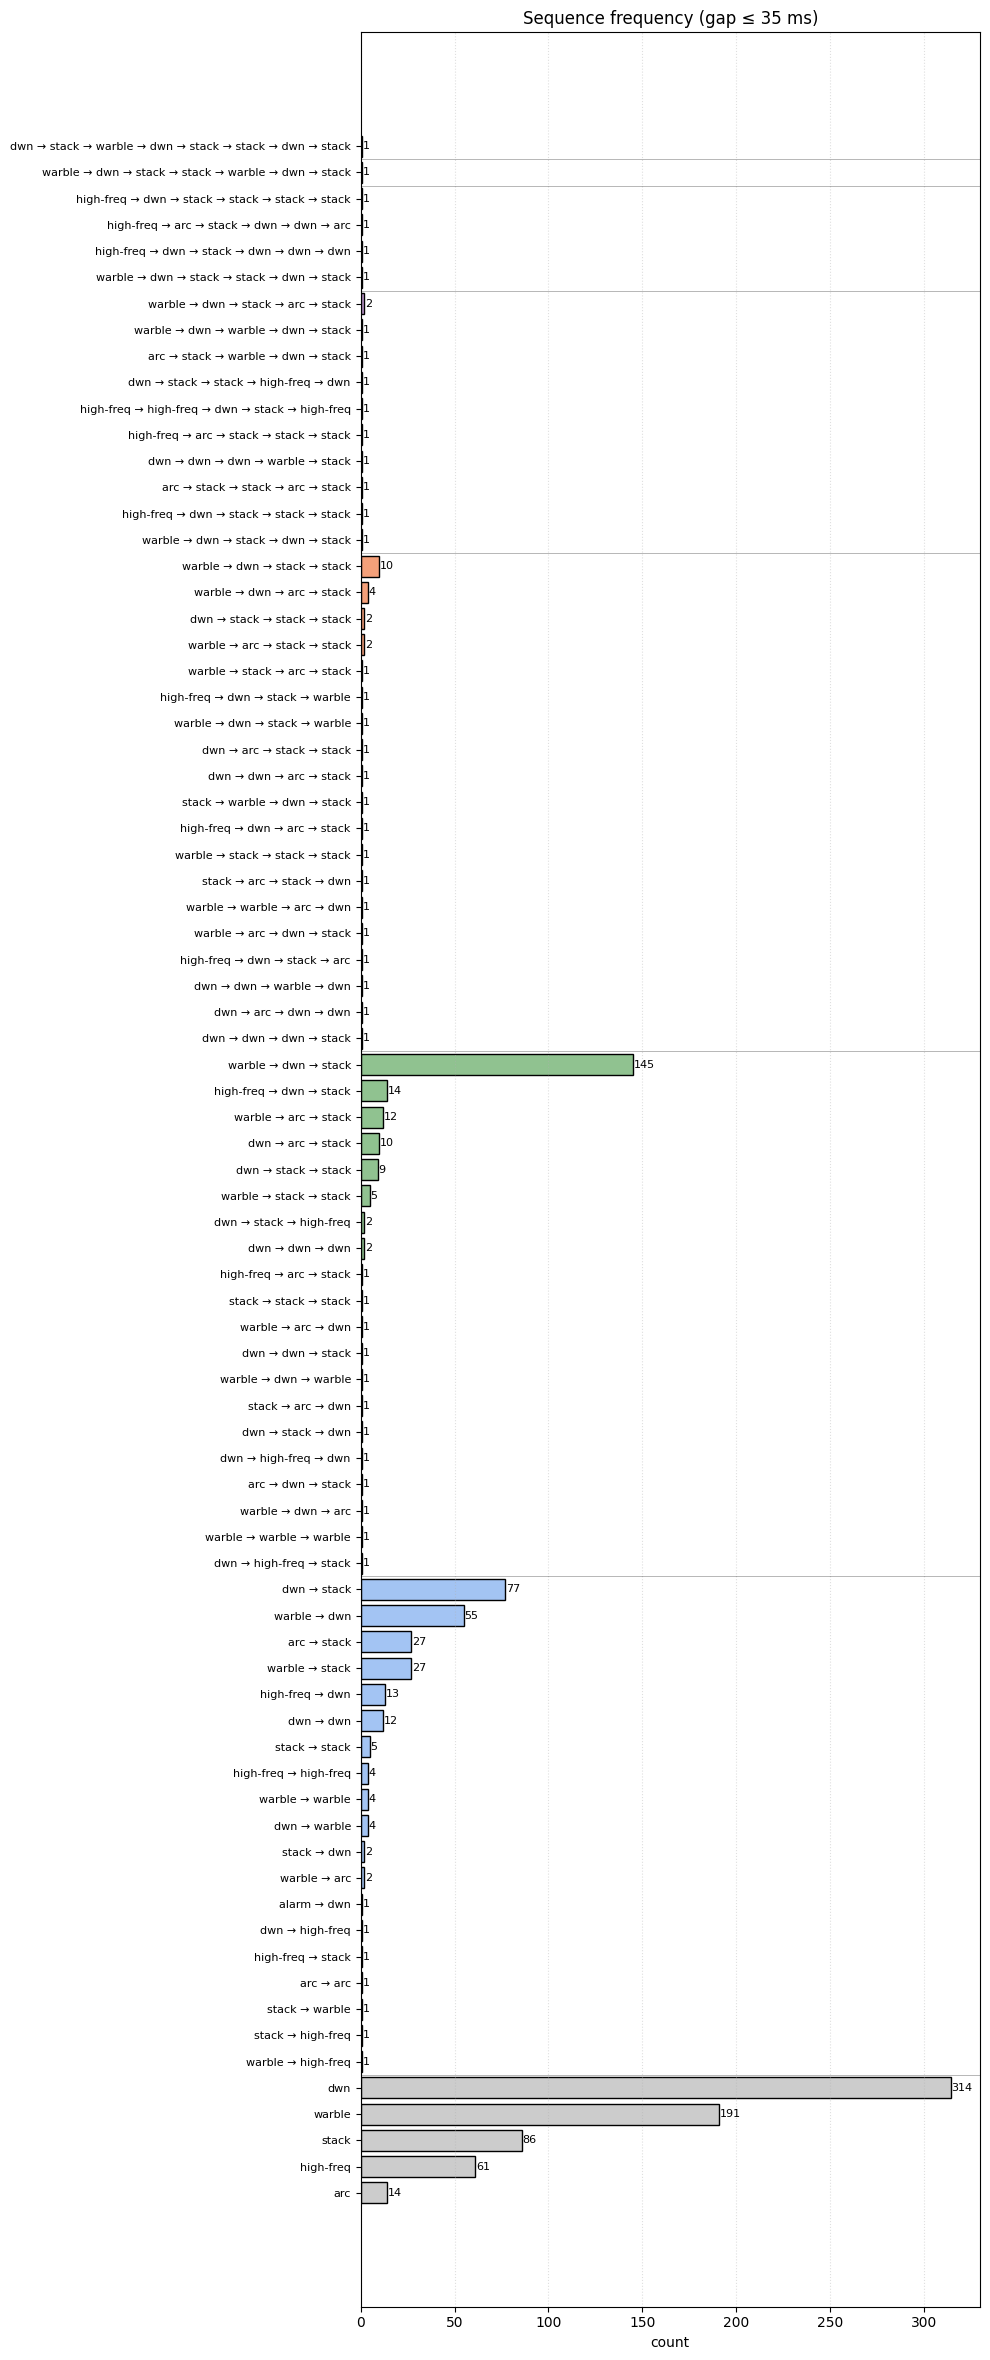

In [5]:
SEQ_THRESHOLD_S = GAP_THRESHOLDS_S[0]  # use the single threshold defined upstream

# Build chains with provenance so each instance can be traced back to a file + time.
chains_meta: list[dict] = []
for stem, df in all_ann.groupby("file_stem", sort=False):
    df = df.sort_values("onset_s").reset_index(drop=True)
    if df.empty:
        continue
    cur_labels: list[str] = [df.iloc[0]["label"]]
    cur_start = float(df.iloc[0]["onset_s"])
    cur_stop = float(df.iloc[0]["offset_s"])
    for i in range(1, len(df)):
        gap = float(df.iloc[i]["onset_s"]) - float(df.iloc[i - 1]["offset_s"])
        if gap <= SEQ_THRESHOLD_S:
            cur_labels.append(df.iloc[i]["label"])
            cur_stop = float(df.iloc[i]["offset_s"])
        else:
            chains_meta.append({
                "sequence": " → ".join(cur_labels),
                "n_syllables": len(cur_labels),
                "file_stem": stem,
                "start_time_s": cur_start,
                "stop_time_s": cur_stop,
            })
            cur_labels = [df.iloc[i]["label"]]
            cur_start = float(df.iloc[i]["onset_s"])
            cur_stop = float(df.iloc[i]["offset_s"])
    chains_meta.append({
        "sequence": " → ".join(cur_labels),
        "n_syllables": len(cur_labels),
        "file_stem": stem,
        "start_time_s": cur_start,
        "stop_time_s": cur_stop,
    })

# `chains` (list of label-lists) is still used by downstream cells.
chains = [m["sequence"].split(" → ") for m in chains_meta]

examples_df = pd.DataFrame(chains_meta)
seq_counts = examples_df["sequence"].value_counts()

# Per-sequence count table grouped by length.
seq_table_rows = []
for k in sorted(examples_df["n_syllables"].unique()):
    sub = examples_df[examples_df["n_syllables"] == k]
    counts_k = sub["sequence"].value_counts()
    for seq, n in counts_k.items():
        seq_table_rows.append({"length": k, "sequence": seq, "count": int(n)})
seq_table = pd.DataFrame(seq_table_rows)

print(f"Threshold: gap ≤ {SEQ_THRESHOLD_S * 1000:.0f} ms")
print(f"Total words: {len(chains_meta)}  |  unique sequences: {len(seq_counts)}\n")
print("Sequence frequency (grouped by syllable count):")
for k in sorted(seq_table["length"].unique()):
    rows = seq_table[seq_table["length"] == k]
    total = rows["count"].sum()
    print(f"\n  {k}-syllable words  ({total} words, {len(rows)} unique sequences)")
    for _, r in rows.iterrows():
        print(f"    {r['count']:3d}  {r['sequence']}")

# Save per-instance examples: one row per word, with file/time provenance.
# Useful for finding specific examples of a given sequence in the data.
examples_out = examples_df.merge(
    seq_counts.rename("sequence_count").reset_index().rename(columns={"index": "sequence"}),
    on="sequence",
    how="left",
)
examples_out = examples_out.sort_values(
    ["n_syllables", "sequence_count", "sequence", "file_stem", "start_time_s"],
    ascending=[False, False, True, True, True],
).reset_index(drop=True)
examples_path = VIZ_DIR / "sequence_examples.csv"
examples_out.to_csv(examples_path, index=False)
print(f"\nSaved per-instance examples → {examples_path}")
print(f"  {len(examples_out)} rows: sequence, n_syllables, file_stem, start_time_s, stop_time_s, sequence_count")

# Horizontal bar chart of sequence frequencies (longest sequences first within each length).
seq_table_sorted = seq_table.sort_values(["length", "count"], ascending=[True, True])
fig, ax = plt.subplots(figsize=(10, max(4, 0.3 * len(seq_table_sorted))))
y = np.arange(len(seq_table_sorted))
length_palette = {1: "#cccccc", 2: "#a3c4f3", 3: "#90c290", 4: "#f4a07a", 5: "#c39bd3"}
colors = [length_palette.get(int(L), "tab:gray") for L in seq_table_sorted["length"]]
ax.barh(y, seq_table_sorted["count"], color=colors, edgecolor="black")
ax.set_yticks(y)
ax.set_yticklabels(seq_table_sorted["sequence"], fontsize=8)
ax.set_xlabel("count")
ax.set_title(f"Sequence frequency (gap ≤ {SEQ_THRESHOLD_S * 1000:.0f} ms)")
for i, c in enumerate(seq_table_sorted["count"]):
    ax.text(c + 0.3, i, str(int(c)), va="center", fontsize=8)
group_breaks = np.where(np.diff(seq_table_sorted["length"].values) != 0)[0]
for b in group_breaks:
    ax.axhline(b + 0.5, color="black", linewidth=0.5, alpha=0.4)
ax.grid(axis="x", linestyle=":", alpha=0.4)
plt.tight_layout()
out_path = VIZ_DIR / "sequence_frequency.png"
fig.savefig(out_path, dpi=120, bbox_inches="tight")
fig.savefig(out_path.with_suffix(".pdf"), dpi=120, bbox_inches="tight")
print(f"\nSaved {out_path} and .pdf")
plt.show()

### Prefix tree of words

Each word is a path from the root. Nodes are labeled with the syllable name and two counts: total words passing through that prefix, and how many ended there. Edge thickness is proportional to count, so the dominant compositional pathways pop visually.

Saved /mnt/home/neurostatslab/ceph/saneslab_data/gily_data/Pre_processing/das/models/TRAINING_data_complex/2026_07_03_dwn_merge/viz_2026_07_03_dwn_merge/prefix_tree.png and .pdf


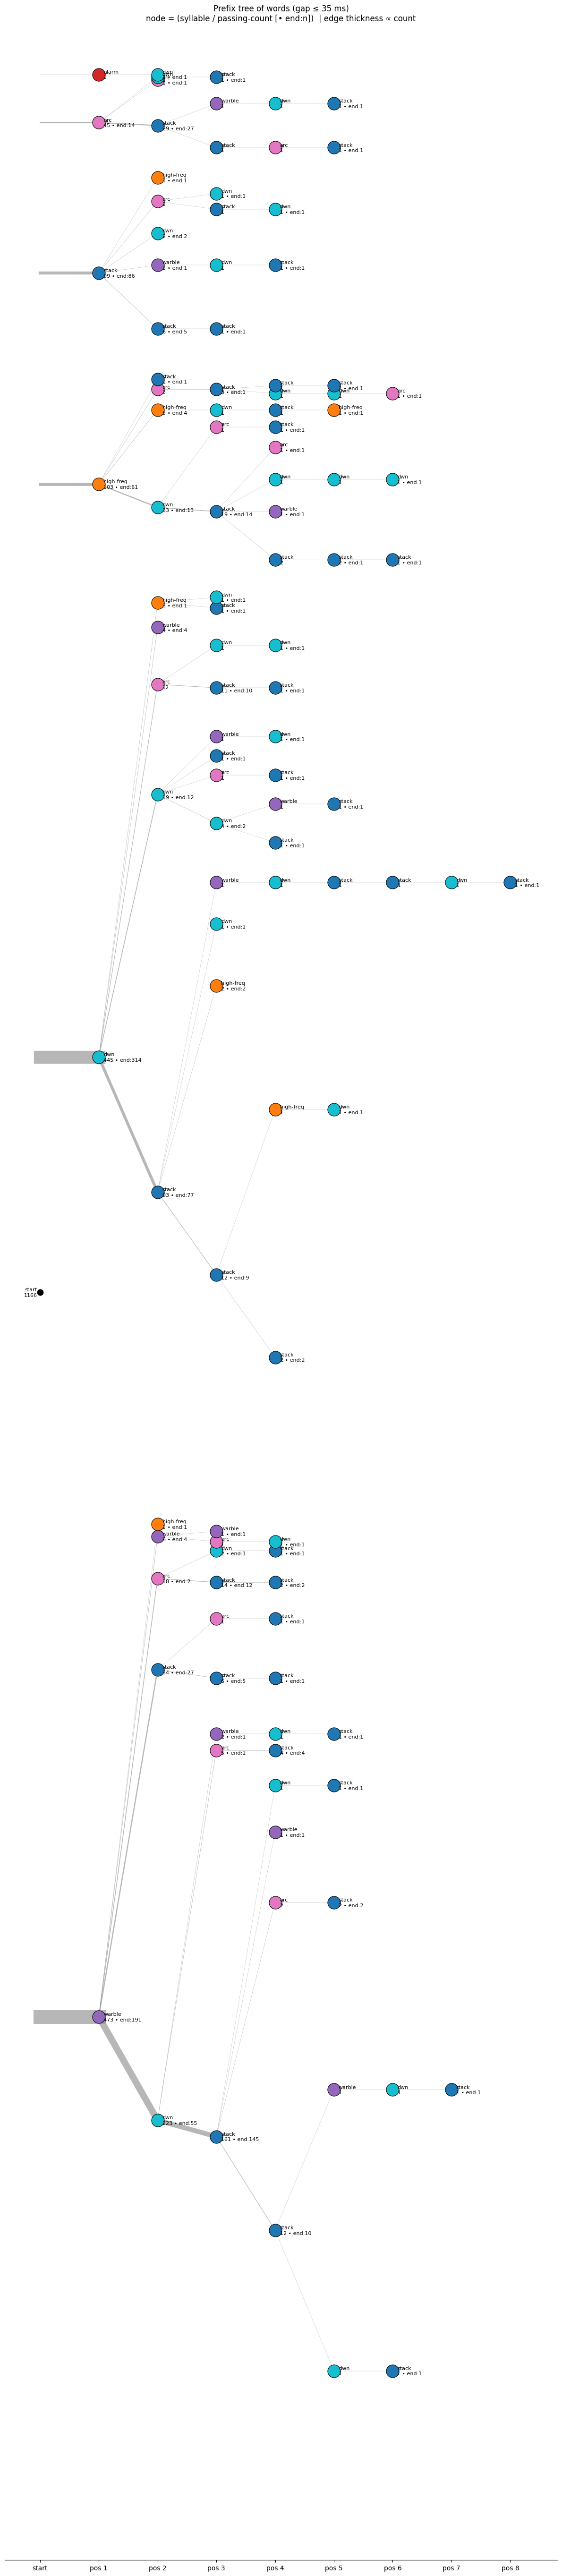

In [7]:
from collections import defaultdict

# Build prefix counts. passing[path] = words whose prefix is path; ending[path] = words that end exactly at path.
passing: dict[tuple[str, ...], int] = defaultdict(int)
ending: dict[tuple[str, ...], int] = defaultdict(int)
for chain in chains:
    for k in range(1, len(chain) + 1):
        passing[tuple(chain[:k])] += 1
    ending[tuple(chain)] += 1

# children_of[parent_path] = list of child paths (one syllable longer).
children_of: dict[tuple[str, ...], list[tuple[str, ...]]] = defaultdict(list)
for p in passing:
    if len(p) > 1:
        children_of[p[:-1]].append(p)

roots = sorted([p for p in passing if len(p) == 1], key=lambda p: -passing[p])
total_words = sum(passing[r] for r in roots)
max_depth = max(len(p) for p in passing)

# Recursive y-allocation: each parent splits its [y_start, y_end] band among
# children proportionally to their passing counts (largest at top).
positions: dict[tuple[str, ...], tuple[int, float]] = {}

def layout(path: tuple[str, ...], y_start: float, y_end: float) -> None:
    positions[path] = (len(path), 0.5 * (y_start + y_end))
    kids = sorted(children_of[path], key=lambda c: -passing[c])
    if not kids:
        return
    total = sum(passing[c] for c in kids)
    cur = y_start
    for k in kids:
        span = (y_end - y_start) * passing[k] / total
        layout(k, cur, cur + span)
        cur += span


cur_y = 0.0
for r in roots:
    span = passing[r] / total_words
    layout(r, cur_y, cur_y + span)
    cur_y += span

fig, ax = plt.subplots(figsize=(12, 0.45 * len(positions) + 2))

# Draw edges first so nodes sit on top.
max_count = max(passing.values())
for path, (x, y) in positions.items():
    if len(path) == 1:
        # Edge from virtual root (x=0) to this position-1 node.
        ax.plot([0, x], [y, y], color="0.6",
                linewidth=0.3 + 20.7 * passing[path] / max_count, alpha=0.7, zorder=1)
    else:
        parent = path[:-1]
        px, py = positions[parent]
        ax.plot([px, x], [py, y], color="0.6",
                linewidth=0.3 + 20.7 * passing[path] / max_count, alpha=0.7, zorder=1)

# Virtual root marker.
ax.scatter([0], [0.5], s=80, color="black", zorder=3)
ax.text(-0.05, 0.5, f"start\n{total_words}", ha="right", va="center", fontsize=8)

# Nodes.
for path, (x, y) in positions.items():
    label = path[-1]
    color = COLORS.get(label, "tab:gray")
    pass_n = passing[path]
    end_n = ending.get(path, 0)
    ax.scatter([x], [y], s=380, color=color, edgecolor="black", linewidth=0.8, zorder=3)
    txt = f"{label}\n{pass_n}"
    if end_n > 0:
        txt += f" • end:{end_n}"
    ax.text(x + 0.08, y, txt, ha="left", va="center", fontsize=8, zorder=4)

ax.set_xlim(-0.6, max_depth + 0.8)
ax.set_ylim(-0.02, 1.02)
ax.set_xticks(range(0, max_depth + 1))
ax.set_xticklabels(["start"] + [f"pos {k}" for k in range(1, max_depth + 1)])
ax.set_yticks([])
for s in ("top", "right", "left"):
    ax.spines[s].set_visible(False)
ax.set_title(
    f"Prefix tree of words (gap ≤ {SEQ_THRESHOLD_S * 1000:.0f} ms)\n"
    f"node = (syllable / passing-count [• end:n])  | edge thickness ∝ count"
)

plt.tight_layout()
out_path = VIZ_DIR / "prefix_tree.png"
fig.savefig(out_path, dpi=120, bbox_inches="tight")
fig.savefig(out_path.with_suffix(".pdf"), dpi=120, bbox_inches="tight")
print(f"Saved {out_path} and .pdf")
plt.show()

## Spectrogram sheets

All the cells that render spectrogram sheets, grouped together. Run the setup cells at the top first.


In [ ]:
# === QA overview: fixed 2-second rows, annotation names written above each call ===
# Run the essentials cell first. Every row spans exactly WINDOW_S seconds (same
# x-range everywhere); a long file uses several rows, a short file leaves the
# right side of its row empty. Rows with no annotations are skipped. Annotations
# whose offset <= onset (inverted / zero-length) are flagged in RED.
import shutil
from matplotlib.patches import Patch

MIN_FREQ, MAX_FREQ = 1_000, 60_000
WINDOW_S = 2.0                 # fixed x-range per row (seconds)
INCHES_PER_SECOND = 7.0        # time scale -> row width
ROW_H = 1.9
ROWS_PER_SHEET = 8
NAME_FS = 6                    # font size for the per-annotation name labels

# --- Detect mishaps up front and print a summary ---
bad = all_ann[all_ann["offset_s"] <= all_ann["onset_s"]].copy()
print(f"{len(bad)} mishap rows (offset <= onset) across "
      f"{bad['file_stem'].nunique()} file(s):")
for _, r in bad.sort_values("file_stem").iterrows():
    print(f"  ⚠ {r['file_stem']:<45} {r['label']:<11} "
          f"on={r['onset_s']:.4f} off={r['offset_s']:.4f} "
          f"(dur={r['offset_s'] - r['onset_s']:+.4f}s)")

# Mirror sheets into the repo (data/ is gitignored but easy to download).
REPO_VIZ_DIR = REPO_ROOT / "data" / "complex_calls_viz" / DATA_DIR.name
REPO_VIZ_DIR.mkdir(parents=True, exist_ok=True)

# --- Precompute per-file annotation spans + audio once ---
_audio: dict[str, tuple] = {}
def _get_audio(path: str):
    if path not in _audio:
        _audio[path] = read_audio(Path(path))
    return _audio[path]

# ann[stem] = list of (lo, hi, on, off, label, inverted)
ann: dict[str, list] = {}
for stem, df in all_ann.groupby("file_stem", sort=False):
    items = []
    for _, r in df.iterrows():
        on, off = float(r["onset_s"]), float(r["offset_s"])
        inv = off <= on
        lo, hi = (off, on) if off < on else (on, off)
        items.append((lo, hi, on, off, str(r["label"]), inv))
    ann[stem] = items

# --- Build fixed-width row windows; keep only windows that contain annotations ---
row_specs = []  # (stem, wav_path, t0, dur, win_idx, n_win)
for stem in ann:
    wav_path = all_ann.loc[all_ann["file_stem"] == stem, "wav_path"].iloc[0]
    fs, x = _get_audio(wav_path)
    dur = x.shape[0] / fs
    n_win = max(1, int(np.ceil(dur / WINDOW_S)))
    for w in range(n_win):
        t0, t1 = w * WINDOW_S, min(dur, (w + 1) * WINDOW_S)
        if any(hi > t0 and lo < t1 for lo, hi, *_ in ann[stem]):
            row_specs.append((stem, wav_path, t0, dur, w, n_win))

n_sheets = int(np.ceil(len(row_specs) / ROWS_PER_SHEET))
print(f"\n{len(row_specs)} non-empty {WINDOW_S:.0f}s rows -> {n_sheets} sheets")

present = [l for l in COLORS if l in set(all_ann["label"])]
legend_handles = [Patch(facecolor=COLORS[l], alpha=0.5, label=l) for l in present]
legend_handles.append(Patch(facecolor="red", alpha=0.5, label="offset <= onset (bad)"))

fig_w = WINDOW_S * INCHES_PER_SECOND
for si in range(n_sheets):
    chunk = row_specs[si * ROWS_PER_SHEET:(si + 1) * ROWS_PER_SHEET]
    fig, axes = plt.subplots(len(chunk), 1, figsize=(fig_w, ROW_H * len(chunk)),
                             squeeze=False)
    axes = axes[:, 0]
    for ax, (stem, wav_path, t0, dur, w, n_win) in zip(axes, chunk):
        t1 = min(dur, t0 + WINDOW_S)
        fs, x = _get_audio(wav_path)
        a, b = int(t0 * fs), int(t1 * fs)
        mesh = plot_spectrogram(ax, x[a:b], fs, min_freq=MIN_FREQ, max_freq=MAX_FREQ,
                                t_start=t0)
        mesh.set_rasterized(True)
        y_lo, y_hi = ax.get_ylim()
        y_name = y_lo + 0.99 * (y_hi - y_lo)   # names sit at the top of the panel

        n_bad = 0
        for lo, hi, on, off, lab, inv in ann[stem]:
            if not (hi > t0 and lo < t1):      # not in this window
                continue
            color = "red" if inv else COLORS.get(lab, "tab:gray")
            if inv:
                n_bad += 1
                ax.axvspan(lo, hi, color="red", alpha=0.30, zorder=3)
                ax.axvline(on, color="red", lw=1.3, zorder=3)
                ax.axvline(off, color="red", lw=1.3, ls=":", zorder=3)
            else:
                ax.axvspan(lo, hi, color=color, alpha=0.15, zorder=1)
                ax.axvline(lo, color=color, lw=0.6, alpha=0.6, zorder=1)
            x_name = min(max(lo, t0), t1)      # clamp name into the window
            ax.text(x_name, y_name, lab, color=color, fontsize=NAME_FS,
                    ha="left", va="top", zorder=4,
                    fontweight=("bold" if inv else "normal"))

        ax.set_xlim(t0, t0 + WINDOW_S)         # always exactly WINDOW_S wide
        tag = f"{stem}" + (f"  [{w + 1}/{n_win}]" if n_win > 1 else "")
        ax.set_title(("⚠ " if n_bad else "") + tag, fontsize=8, loc="left",
                     color=("red" if n_bad else "black"))
        ax.set_xlabel("")
        ax.set_ylabel("kHz", fontsize=7)
        ax.tick_params(labelsize=6)

    fig.legend(handles=legend_handles, loc="upper right", ncol=len(legend_handles),
               fontsize=7, frameon=False, bbox_to_anchor=(1.0, 1.01))
    fig.suptitle(f"QA overview ({WINDOW_S:.0f}s rows) — sheet {si + 1}/{n_sheets}  "
                 f"({DATA_DIR.name})", y=1.005, x=0.01, ha="left")
    plt.tight_layout()
    stem_out = f"qa_overview_sheet_{si + 1:02d}.png"
    fig.savefig(REPO_VIZ_DIR / stem_out, dpi=110, bbox_inches="tight")   # render once
    shutil.copyfile(REPO_VIZ_DIR / stem_out, VIZ_DIR / stem_out)          # cheap copy
    print(f"saved {stem_out} -> {VIZ_DIR} and {REPO_VIZ_DIR}")
    plt.show()


## 1. All files together

Each row = one wav. Spectrogram with annotation spans + labels overlaid. Files have different durations, so x-limits are per-file.

In [ ]:

SECONDS_PER_ROW = 1.0
INCHES_PER_SECOND = 10.0  # fixed time-axis scale; do not stretch to page
ROW_HEIGHT = 2.2
ROWS_PER_SHEET = 5

# Mirror figures into the repo (data/ is gitignored) for easy download.
REPO_VIZ_DIR = REPO_ROOT / "data" / "complex_calls_viz" / DATA_DIR.name
REPO_VIZ_DIR.mkdir(parents=True, exist_ok=True)

# Cache audio + annotations per file once.
file_data: dict[Path, tuple[int, np.ndarray, pd.DataFrame]] = {}
for wav, csv in pairs:
    fs, x = read_audio(wav)
    file_data[wav] = (fs, x, load_annotations(csv))

# Build row layout, then drop rows that contain no annotations.
row_specs: list[tuple[Path, float, float, int, int]] = []
for wav, _csv in pairs:
    fs, x, df = file_data[wav]
    dur = x.shape[0] / fs
    n_rows = max(1, int(np.ceil(dur / SECONDS_PER_ROW)))
    for r in range(n_rows):
        t0 = r * SECONDS_PER_ROW
        t1 = min(dur, (r + 1) * SECONDS_PER_ROW)
        df_row = df[(df["offset_s"] > t0) & (df["onset_s"] < t1)]
        if len(df_row) == 0:
            continue
        row_specs.append((wav, t0, t1, r, n_rows))

n_total_rows = len(row_specs)
n_sheets = int(np.ceil(n_total_rows / ROWS_PER_SHEET))
print(f"{n_total_rows} non-empty rows → {n_sheets} sheets of up to {ROWS_PER_SHEET} rows each.")

fig_w = SECONDS_PER_ROW * INCHES_PER_SECOND
for sheet_idx in range(n_sheets):
    chunk = row_specs[sheet_idx * ROWS_PER_SHEET : (sheet_idx + 1) * ROWS_PER_SHEET]
    fig, axes = plt.subplots(len(chunk), 1, figsize=(fig_w, ROW_HEIGHT * len(chunk)), squeeze=False)
    axes = axes[:, 0]
    for ax, (wav, t0, t1, r, n_rows) in zip(axes, chunk):
        fs, x, df = file_data[wav]
        a = int(t0 * fs)
        b = int(t1 * fs)
        mesh = plot_spectrogram(
            ax, x[a:b], fs, min_freq=MIN_FREQ, max_freq=MAX_FREQ, t_start=t0
        )
        # Rasterize the dense pcolormesh layer so PDFs stay small;
        # axes/text/overlay lines remain vector.
        mesh.set_rasterized(True)
        df_row = df[(df["offset_s"] > t0) & (df["onset_s"] < t1)]
        plot_segments_overlay(ax, df_row, color_map=COLORS, with_text=True, text_y_frac=0.92)
        title = wav.stem if r == 0 else f"{wav.stem}  (cont. {r + 1}/{n_rows})"
        ax.set_title(title, fontsize=9, loc="left")
        ax.set_xlim(t0, t0 + SECONDS_PER_ROW)
    fig.suptitle(
        f"Complex-call training set — sheet {sheet_idx + 1}/{n_sheets}",
        y=1.001,
    )
    plt.tight_layout()
    stem = f"all_files_sheet_{sheet_idx + 1:02d}"
    for ext in ("png", "pdf"):
        for d in (VIZ_DIR, REPO_VIZ_DIR):
            fig.savefig(d / f"{stem}.{ext}", dpi=120, bbox_inches="tight")
    print(f"Saved {stem}.{{png,pdf}} \u2192 {VIZ_DIR} and {REPO_VIZ_DIR}")
    plt.show()

## 2. Per-call-type — every instance side-by-side

One figure per label. Each panel shows a single annotated segment with a small time pad on either side, so you can compare shape/bandwidth/duration across instances. The bordered red lines mark the human-annotated onset/offset.

What to look for:
- Are panels within a label visually consistent? (legitimate type)
- Are there subgroups that look qualitatively different? (over-splitting candidate, or a missing sub-type)
- Are onset/offset boundaries consistent (e.g. always tight, or sometimes leaving silence)?

In [ ]:
import shutil

PAD_S = 0.05  # seconds of context before/after each call window
PANELS_PER_ROW = 8
ROWS_PER_SHEET = 12         # large types are split into multiple sheets
PANELS_PER_SHEET = PANELS_PER_ROW * ROWS_PER_SHEET
INCHES_PER_SECOND = 3.0  # fixed time-axis scale shared by every panel
PANEL_H = 1.6

# Mirror figures into the repo (data/ is gitignored) for easy download.
REPO_VIZ_DIR = REPO_ROOT / "data" / "complex_calls_viz" / DATA_DIR.name
REPO_VIZ_DIR.mkdir(parents=True, exist_ok=True)

# Fixed 1-second window per panel (shared by every call-type figure) so call
# durations are visually comparable and more panels pack into each sheet.
WINDOW_S = 1.0
PANEL_W = INCHES_PER_SECOND * WINDOW_S
print(f"Fixed window per panel: {WINDOW_S * 1000:.0f} ms ({PANEL_W:.2f} in wide).")

# Cache audio per file so we don't re-read for every call.
audio_cache: dict[str, tuple[int, np.ndarray]] = {}

def get_audio(path: str) -> tuple[int, np.ndarray]:
    if path not in audio_cache:
        audio_cache[path] = read_audio(Path(path))
    return audio_cache[path]


def call_window(on: float, off: float, dur_s: float) -> tuple[float, float]:
    """Return [t0, t1] of length WINDOW_S, centered on the call but clamped to [0, dur_s]."""
    lo, hi = (off, on) if off < on else (on, off)   # handle inverted rows
    mid = 0.5 * (lo + hi)
    t0 = mid - WINDOW_S / 2
    t1 = mid + WINDOW_S / 2
    if t0 < 0:
        t0, t1 = 0.0, WINDOW_S
    if t1 > dur_s:
        t1 = dur_s
        t0 = max(0.0, t1 - WINDOW_S)
    return t0, t1


def plot_calls_for_label(label: str, sub: pd.DataFrame) -> None:
    n_calls = len(sub)
    color = COLORS.get(label, "tab:gray")
    n_sheets = int(np.ceil(n_calls / PANELS_PER_SHEET))
    for si in range(n_sheets):
        part = sub.iloc[si * PANELS_PER_SHEET:(si + 1) * PANELS_PER_SHEET].reset_index(drop=True)
        n_p = len(part)
        n_cols = min(PANELS_PER_ROW, n_p)
        n_rows = int(np.ceil(n_p / n_cols))
        fig, axes = plt.subplots(
            n_rows, n_cols, figsize=(PANEL_W * n_cols, PANEL_H * n_rows), squeeze=False
        )
        for ax_idx, (_, row) in enumerate(part.iterrows()):
            ax = axes[ax_idx // n_cols, ax_idx % n_cols]
            fs, x = get_audio(row["wav_path"])
            on, off = float(row["onset_s"]), float(row["offset_s"])
            inverted = off <= on
            dur_s = x.shape[0] / fs
            t0, t1 = call_window(on, off, dur_s)
            a, b = int(t0 * fs), int(t1 * fs)
            plot_spectrogram(
                ax, x[a:b], fs, min_freq=MIN_FREQ, max_freq=MAX_FREQ, t_start=t0
            )
            mk = "red" if inverted else color
            ax.axvline(on, color=mk, linewidth=1.2, alpha=0.9)
            ax.axvline(off, color=mk, linewidth=1.2, alpha=0.9,
                       linestyle=(":" if inverted else "-"))
            if inverted:                       # flag bad rows: red span + red border
                ax.axvspan(off, on, color="red", alpha=0.25)
                for sp in ax.spines.values():
                    sp.set_color("red"); sp.set_linewidth(1.6)
            # Force every panel to span the same number of seconds.
            ax.set_xlim(t0, t0 + WINDOW_S)
            ax.set_title(
                ("⚠ " if inverted else "") + f"{row['file_stem'][-28:]}  {(off-on)*1000:.0f} ms",
                fontsize=7, color=("red" if inverted else "black"),
            )
            ax.set_xlabel("")
            ax.set_ylabel("")
            ax.tick_params(labelsize=6)

        # Hide unused axes in last row.
        for ax_idx in range(n_p, n_rows * n_cols):
            axes[ax_idx // n_cols, ax_idx % n_cols].axis("off")

        sheet_tag = "" if n_sheets == 1 else f"  [sheet {si + 1}/{n_sheets}]"
        fig.suptitle(f"{label} — {n_calls} instances{sheet_tag}", color=color, fontsize=12, y=1.001)
        plt.tight_layout()
        safe_label = label.replace("/", "_")
        suffix = "" if n_sheets == 1 else f"_sheet_{si + 1:02d}"
        stem_out = f"per_type__{safe_label}{suffix}.png"
        fig.savefig(REPO_VIZ_DIR / stem_out, dpi=120, bbox_inches="tight")   # render once
        shutil.copyfile(REPO_VIZ_DIR / stem_out, VIZ_DIR / stem_out)          # cheap copy
        print(f"Saved {stem_out} → {VIZ_DIR} and {REPO_VIZ_DIR}")
        plt.show()


# Iterate from most to least common label so you see the bulk types first.
label_order = all_ann["label"].value_counts().index.tolist()
for lbl in label_order:
    plot_calls_for_label(lbl, all_ann[all_ann["label"] == lbl].reset_index(drop=True))


### Per-sequence — every instance of each word

One figure per unique multi-syllable sequence (≥ `SEQ_MIN_INSTANCES` occurrences).
All panels in a figure share one time window, with each syllable labeled. Depends on `examples_df`.


In [ ]:
import shutil

SEQ_PAD_S = 0.05
SEQ_PANELS_PER_ROW = 5
SEQ_ROWS_PER_SHEET = 8            # large sequences split into multiple sheets
SEQ_PANELS_PER_SHEET = SEQ_PANELS_PER_ROW * SEQ_ROWS_PER_SHEET
SEQ_INCHES_PER_SECOND = 6.0
SEQ_PANEL_H = 1.8
SEQ_MIN_INSTANCES = 3            # only plot sequences seen at least this many times
SPEC_CMAP = "magma"              # spectrogram colormap (viridis / magma / inferno / gray_r)
SPEC_VMIN = -50.0                # dB floor: lower = more faint detail (noisier); -40 was default
SPEC_VMAX = 0.0                  # dB ceiling (0 = per-clip peak)
# Sequences to skip entirely (over-split same-label repeats).
DROP_SEQUENCES = {("warble", "warble"), ("stack", "stack")}

REPO_VIZ_DIR = REPO_ROOT / "data" / "complex_calls_viz" / DATA_DIR.name
REPO_VIZ_DIR.mkdir(parents=True, exist_ok=True)

# Audio cache for word-window plotting (independent of the per-call-type cache).
seq_audio_cache: dict[str, tuple[int, np.ndarray]] = {}


def _get_audio_for_stem(stem: str) -> tuple[int, np.ndarray]:
    if stem not in seq_audio_cache:
        wav = DATA_DIR / f"{stem}.wav"
        fs, x = read_audio(wav)
        seq_audio_cache[stem] = (fs, x)
    return seq_audio_cache[stem]


def _safe_filename(seq: str) -> str:
    return seq.replace(" → ", "__").replace("/", "_").replace(" ", "_")


# One figure per unique multi-syllable sequence. Within each figure, panels
# share the same time-axis width = max word duration in that sequence + pad,
# so all instances are directly comparable.
multi_word = examples_df[examples_df["n_syllables"] >= 2].copy()
multi_word["dur_s"] = multi_word["stop_time_s"] - multi_word["start_time_s"]

# Order: shorter sequences first, most frequent within each length first.
seq_order = (
    multi_word.groupby("sequence")
    .agg(n=("file_stem", "size"), n_syl=("n_syllables", "first"))
    .sort_values(["n_syl", "n"], ascending=[True, False])
    .reset_index()
)
n_total = len(seq_order)
seq_order = seq_order[seq_order["n"] >= SEQ_MIN_INSTANCES].reset_index(drop=True)
_drop = {" → ".join(t) for t in DROP_SEQUENCES}
seq_order = seq_order[~seq_order["sequence"].isin(_drop)].reset_index(drop=True)
print(f"Plotting {len(seq_order)} sequences with ≥ {SEQ_MIN_INSTANCES} instances "
      f"(of {n_total} multi-syllable sequences).")

for seq_str, n_inst, n_syl in seq_order[["sequence", "n", "n_syl"]].itertuples(index=False):
    group = multi_word[multi_word["sequence"] == seq_str].reset_index(drop=True)
    window_s = float(group["dur_s"].max()) + 2 * SEQ_PAD_S
    panel_w = SEQ_INCHES_PER_SECOND * window_s
    n_inst = len(group)
    n_sheets = int(np.ceil(n_inst / SEQ_PANELS_PER_SHEET))

    for si in range(n_sheets):
        part = group.iloc[si * SEQ_PANELS_PER_SHEET:(si + 1) * SEQ_PANELS_PER_SHEET].reset_index(drop=True)
        n_p = len(part)
        n_cols = min(SEQ_PANELS_PER_ROW, n_p)
        n_rows = int(np.ceil(n_p / n_cols))
        fig, axes = plt.subplots(
            n_rows, n_cols,
            figsize=(panel_w * n_cols, SEQ_PANEL_H * n_rows),
            squeeze=False,
        )

        for ax_idx, row in part.iterrows():
            ax = axes[ax_idx // n_cols, ax_idx % n_cols]
            fs, x = _get_audio_for_stem(row["file_stem"])
            dur_file = x.shape[0] / fs
            mid = 0.5 * (row["start_time_s"] + row["stop_time_s"])
            t0 = mid - window_s / 2
            t1 = mid + window_s / 2
            if t0 < 0:
                t0, t1 = 0.0, window_s
            if t1 > dur_file:
                t1 = dur_file
                t0 = max(0.0, t1 - window_s)
            a, b = int(t0 * fs), int(t1 * fs)
            mesh = plot_spectrogram(
                ax, x[a:b], fs, min_freq=MIN_FREQ, max_freq=MAX_FREQ, t_start=t0,
                cmap=SPEC_CMAP, vmin=SPEC_VMIN, vmax=SPEC_VMAX,
            )
            mesh.set_rasterized(True)

            # Overlay each syllable in the word with its label.
            seg_df = all_ann[
                (all_ann["file_stem"] == row["file_stem"])
                & (all_ann["onset_s"] >= row["start_time_s"] - 1e-3)
                & (all_ann["offset_s"] <= row["stop_time_s"] + 1e-3)
            ].sort_values("onset_s")
            plot_segments_overlay(
                ax, seg_df, color_map=COLORS, with_text=True,
                text_y_frac=0.92, text_fontsize=7,
            )

            ax.set_xlim(t0, t0 + window_s)
            ax.set_title(f"{row['file_stem'][-25:]}  {row['dur_s']*1000:.0f} ms", fontsize=7)
            ax.set_xlabel("")
            ax.set_ylabel("")
            ax.tick_params(labelsize=6)

        for ax_idx in range(n_p, n_rows * n_cols):
            axes[ax_idx // n_cols, ax_idx % n_cols].axis("off")

        sheet_tag = "" if n_sheets == 1 else f"   [sheet {si + 1}/{n_sheets}]"
        fig.suptitle(f"{seq_str}   (n={n_inst}){sheet_tag}", fontsize=12, y=1.001)
        plt.tight_layout()
        suffix = "" if n_sheets == 1 else f"_sheet_{si + 1:02d}"
        stem_out = f"per_seq__{_safe_filename(seq_str)}{suffix}.png"
        fig.savefig(REPO_VIZ_DIR / stem_out, dpi=120, bbox_inches="tight")   # render once
        shutil.copyfile(REPO_VIZ_DIR / stem_out, VIZ_DIR / stem_out)          # cheap copy
        plt.show()

print(f"\nSaved {len(seq_order)} sequences → {VIZ_DIR} and {REPO_VIZ_DIR}")


## Poster / talk version plots

Large-font, presentation-ready variants of figures defined earlier in the notebook.

Each depends on its upstream cell having been run first:
- poster alluvial + highlighted alluvial → `Pooled alluvial across all word lengths`
- talk transition matrix → `Within-word transition matrix — comparable-style version`


In [ ]:
# Poster version of the pooled alluvial: same layout as the cell above, large
# fonts, no title. Run the pooled-alluvial cell first (it builds blocks_pool etc.).
from matplotlib.patches import Rectangle, PathPatch
from matplotlib.path import Path as _MPath

# === The one knob to change ===
POSTER_FONT = 20

fig, ax = plt.subplots(figsize=(2.8 * max_k_pool + 2.5, 9))

for (col, sy0, sy1, ty0, ty1, color) in flows_pool:
    x0 = col + BLOCK_W
    x1 = col + 1
    mid = 0.5 * (x0 + x1)
    verts = [
        (x0, sy0),
        (mid, sy0), (mid, ty0), (x1, ty0),
        (x1, ty1),
        (mid, ty1), (mid, sy1), (x0, sy1),
        (x0, sy0),
    ]
    codes = [
        _MPath.MOVETO,
        _MPath.CURVE4, _MPath.CURVE4, _MPath.CURVE4,
        _MPath.LINETO,
        _MPath.CURVE4, _MPath.CURVE4, _MPath.CURVE4,
        _MPath.CLOSEPOLY,
    ]
    ax.add_patch(PathPatch(_MPath(verts, codes), facecolor=color,
                           edgecolor="none", alpha=0.6, zorder=1))

for col in range(max_k_pool):
    for lab, (y0, y1) in blocks_pool[col].items():
        color = COLORS.get(lab, "tab:gray")
        ax.add_patch(Rectangle((col, y0), BLOCK_W, y1 - y0,
                               facecolor=color, edgecolor="black",
                               linewidth=1.0, zorder=2))
        # Hatched overlay on the portion that ends here (no outgoing ribbon).
        ends = ending_counts[col].get(lab, 0)
        if ends > 0:
            end_h = ends / n_pool
            ax.add_patch(Rectangle((col, y1 - end_h), BLOCK_W, end_h,
                                   facecolor="none", edgecolor="black",
                                   hatch="////", linewidth=0.8, zorder=2.5))
        if (y1 - y0) > 0.025:
            if col == 0:
                # First position: labels to the LEFT of the colored bars.
                ax.text(col - 0.05, 0.5 * (y0 + y1),
                        lab, ha="right", va="center", fontsize=POSTER_FONT, zorder=3)
            else:
                ax.text(col + BLOCK_W + 0.05, 0.5 * (y0 + y1),
                        lab, ha="left", va="center", fontsize=POSTER_FONT, zorder=3)

n_active_per_pos = [
    sum(int(round((b[1] - b[0]) * n_pool)) for b in bp.values())
    for bp in blocks_pool
]
ax.set_xticks([col + BLOCK_W / 2 for col in range(max_k_pool)])
ax.set_xticklabels(
    [f"pos {col + 1}\n({n / n_pool * 100:.0f}%)" for col, n in enumerate(n_active_per_pos)],
    fontsize=POSTER_FONT,
)

ax.set_xlim(-0.15, max_k_pool - 1 + BLOCK_W + 2.4)
ax.set_ylim(-0.04, y_max + 0.04)
ax.invert_yaxis()
ax.set_yticks([])
for s in ("top", "right", "left"):
    ax.spines[s].set_visible(False)
plt.tight_layout()
out_path = VIZ_DIR / "alluvial_pooled_poster.png"
fig.savefig(out_path, dpi=200, bbox_inches="tight")
fig.savefig(out_path.with_suffix(".pdf"), dpi=200, bbox_inches="tight")
print(f"Saved {out_path} and .pdf")
plt.show()


In [ ]:
# Highlighted versions of the pooled alluvial for talk slides.
# Same layout as the cell above, but with specific word paths shown in full
# colour while everything else is washed out by a translucent white overlay.

def _plot_highlighted_alluvial(highlight_seq: list[str], filename_suffix: str,
                               wash_alpha: float = 0.78) -> None:
    """Draw the pooled alluvial with one specific path highlighted.

    ``highlight_seq[i]`` is the label kept un-washed at position ``i + 1``;
    flows between consecutive entries are also kept. Re-uses ``chains_pool``,
    ``blocks_pool``, ``trans_pool``, ``orders_pool``, ``label_idx_pool``,
    ``ending_counts``, ``n_pool``, ``max_k_pool``, ``y_max``, ``GAP_FRAC``,
    ``BLOCK_W`` from the cell above (must be run first).
    """
    # Recompute flow bands but keep src/tgt so we can decide what to highlight.
    flows: list[tuple[int, str, str, float, float, float, float]] = []
    for col in range(max_k_pool - 1):
        outgoing: dict[str, list[tuple[str, int]]] = defaultdict(list)
        incoming: dict[str, list[tuple[str, int]]] = defaultdict(list)
        for (src, tgt), c in trans_pool[col].items():
            outgoing[src].append((tgt, c))
            incoming[tgt].append((src, c))
        for lst in outgoing.values():
            lst.sort(key=lambda x: label_idx_pool[col + 1][x[0]])
        for lst in incoming.values():
            lst.sort(key=lambda x: label_idx_pool[col][x[0]])
        src_cursor = {lab: blocks_pool[col][lab][0] for lab in blocks_pool[col]}
        tgt_cursor = {lab: blocks_pool[col + 1][lab][0] for lab in blocks_pool[col + 1]}
        src_band: dict[tuple[str, str], tuple[float, float]] = {}
        tgt_band: dict[tuple[str, str], tuple[float, float]] = {}
        for src, fs in outgoing.items():
            for tgt, c in fs:
                y0 = src_cursor[src]
                h = c / n_pool
                src_band[(src, tgt)] = (y0, y0 + h)
                src_cursor[src] = y0 + h
        for tgt, fs in incoming.items():
            for src, c in fs:
                y0 = tgt_cursor[tgt]
                h = c / n_pool
                tgt_band[(src, tgt)] = (y0, y0 + h)
                tgt_cursor[tgt] = y0 + h
        for (src, tgt) in trans_pool[col]:
            sy0, sy1 = src_band[(src, tgt)]
            ty0, ty1 = tgt_band[(src, tgt)]
            flows.append((col, src, tgt, sy0, sy1, ty0, ty1))

    def flow_is_highlit(col: int, src: str, tgt: str) -> bool:
        return (col < len(highlight_seq) - 1
                and highlight_seq[col] == src
                and highlight_seq[col + 1] == tgt)

    def block_is_highlit(col: int, lab: str) -> bool:
        return col < len(highlight_seq) and highlight_seq[col] == lab

    wash = (1.0, 1.0, 1.0, wash_alpha)

    fig, ax = plt.subplots(figsize=(2.4 * max_k_pool + 2, 6))

    # Flows.
    for col, src, tgt, sy0, sy1, ty0, ty1 in flows:
        color = COLORS.get(src, "tab:gray")
        x0 = col + BLOCK_W
        x1 = col + 1
        mid = 0.5 * (x0 + x1)
        verts = [
            (x0, sy0),
            (mid, sy0), (mid, ty0), (x1, ty0),
            (x1, ty1),
            (mid, ty1), (mid, sy1), (x0, sy1),
            (x0, sy0),
        ]
        codes = [
            _MPath.MOVETO,
            _MPath.CURVE4, _MPath.CURVE4, _MPath.CURVE4,
            _MPath.LINETO,
            _MPath.CURVE4, _MPath.CURVE4, _MPath.CURVE4,
            _MPath.CLOSEPOLY,
        ]
        flow_z = 1.9 if flow_is_highlit(col, src, tgt) else 1.0
        ax.add_patch(PathPatch(_MPath(verts, codes), facecolor=color,
                               edgecolor="none", alpha=0.6, zorder=flow_z))
        if not flow_is_highlit(col, src, tgt):
            ax.add_patch(PathPatch(_MPath(verts, codes), facecolor=wash,
                                   edgecolor="none", zorder=1.5))

    # Blocks + ending hatch + per-block wash for non-highlit ones.
    for col in range(max_k_pool):
        for lab, (y0, y1) in blocks_pool[col].items():
            color = COLORS.get(lab, "tab:gray")
            hl = block_is_highlit(col, lab)
            block_z = 3.0 if hl else 2.0
            hatch_z = 3.2 if hl else 2.5
            ax.add_patch(Rectangle((col, y0), BLOCK_W, y1 - y0,
                                   facecolor=color, edgecolor="black",
                                   linewidth=0.6, zorder=block_z))
            ends = ending_counts[col].get(lab, 0)
            if ends > 0:
                end_h = ends / n_pool
                ax.add_patch(Rectangle((col, y1 - end_h), BLOCK_W, end_h,
                                       facecolor="none", edgecolor="black",
                                       hatch="////", linewidth=0.5, zorder=hatch_z))
            if not hl:
                ax.add_patch(Rectangle((col, y0), BLOCK_W, y1 - y0,
                                       facecolor=wash, edgecolor="none",
                                       zorder=2.75))
            if (y1 - y0) > 0.025:
                txt_color = "black" if hl else (0.55, 0.55, 0.55)
                txt_z = 3.5 if hl else 2.9
                ax.text(col + BLOCK_W + 0.04, 0.5 * (y0 + y1),
                        lab, ha="left", va="center", fontsize=8,
                        color=txt_color, zorder=txt_z)

    n_active_per_pos = [
        sum(int(round((b[1] - b[0]) * n_pool)) for b in bp.values())
        for bp in blocks_pool
    ]
    ax.set_xticks([col + BLOCK_W / 2 for col in range(max_k_pool)])
    ax.set_xticklabels(
        [f"pos {col + 1}\n({n / n_pool * 100:.0f}%)" for col, n in enumerate(n_active_per_pos)],
        fontsize=9,
    )
    ax.set_xlim(-0.15, max_k_pool - 1 + BLOCK_W + 1.6)
    ax.set_ylim(-0.04, y_max + 0.04)
    ax.invert_yaxis()
    ax.set_yticks([])
    for s in ("top", "right", "left"):
        ax.spines[s].set_visible(False)
    ax.set_title(
        f"Pooled lengths (n={n_pool} words, len>=2) — highlight: "
        + " → ".join(highlight_seq)
    )
    plt.tight_layout()
    out_path = VIZ_DIR / f"alluvial_pooled_highlight_{filename_suffix}.png"
    fig.savefig(out_path, dpi=120, bbox_inches="tight")
    fig.savefig(out_path.with_suffix(".pdf"), dpi=120, bbox_inches="tight")
    print(f"Saved {out_path} and .pdf")
    plt.show()


_plot_highlighted_alluvial(["warble", "half-arc", "stack"], "warble_halfarc_stack")
_plot_highlighted_alluvial(["arc", "stack"], "arc_stack")


In [ ]:
# Talk version of the within-word transition matrix. Large fonts, colorbar.
# Reads TM_FULL, stashed by the "comparable-style" matrix cell, so it is immune to
# the collapsed-5-class cell overwriting P / n_labels / display_labels.
FS = 20

P = TM_FULL["P"]
display_labels = TM_FULL["display_labels"]
n_labels = TM_FULL["n_labels"]
n_trans = TM_FULL["n_trans"]
band_label = TM_FULL["band_label"]

fig, ax = plt.subplots(figsize=(8, 7))
im = ax.imshow(P, cmap="Greens", vmin=0, vmax=1)

ax.set_xticks(range(n_labels))
ax.set_xticklabels(display_labels, rotation=40, ha="right", fontsize=FS)
ax.set_yticks(range(n_labels))
ax.set_yticklabels(display_labels, fontsize=FS)
ax.set_title(f"{band_label}  (n={n_trans:,})", fontsize=FS, pad=20)
ax.set_ylabel("current call", fontsize=FS)
ax.set_xlabel("next call", fontsize=FS)

cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
cbar.set_ticks([0, 1])
cbar.set_ticklabels(["0", "1"])
cbar.ax.tick_params(labelsize=FS)
cbar.set_label("P(next | current)", fontsize=FS)

fig.tight_layout()
out_path = VIZ_DIR / "transition_matrix_within_word_talk.png"
fig.savefig(out_path, dpi=200, bbox_inches="tight")
fig.savefig(out_path.with_suffix(".pdf"), dpi=200, bbox_inches="tight")
print(f"Saved {out_path} and .pdf")
plt.show()
